In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple

# Opcional: solver de referència (implementació de biblioteca)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from QPGC import QPGenericConstraints


## Theoretical Background

For understand correctly the objectives of this practical delivery, we must take into account the following theorical approach for implement Support Vector Machines (SVMs) classifiers, most of those concepts had been explaind on Practical 5 and the update of Practical 6 concerns to optimization method needed to solve the unconstrained primal problem by Stochastic Gradient Descent and mini-batch approach. So, just remembering from last practical lesson, SVMs are supervised learning methods designed to address binary classification problems by constructing a separating hyperplane with maximum margin. 

In this case, given a training dataset $\{(x_i, y_i)\}_{i=1}^m$ with input vectors $x_i \in \mathbb{R}^n$ and labels $y_i \in \{-1, +1\}$, the objective is not only to correctly classify the samples but to do so in a way that maximizes robustness and generalization. This robustness is achieved by maximizing the margin, understood as the minimum distance between the separating hyperplane and the closest data points from each class.

In the linearly separable case, the classifier is defined by the affine function 

$$ f(x) = w^T x + b $$

where $w$ is the normal vector to the hyperplane and $b$ is a bias term. Correct classification with a margin constraint requires that all training samples satisfy 

$$y_i (w^T x_i + b) \geq 1$$

The margin corresponds to the distance between the two parallel hyperplanes $f(x) = 1$ and $f(x) = -1$, which can be shown to be equal to $2 / \|w\|$. Therefore, maximizing the margin is equivalent to minimizing the squared Euclidean norm of the weight vector.

This leads to the primal optimization problem:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1$$

This is a convex optimization problem with linear inequality constraints. Instead of solving it directly, it is advantageous to derive its dual formulation using the method of Lagrange multipliers. Introducing multipliers $\alpha_i \geq 0$ associated with each constraint, the Lagrangian is defined as 

$$\mathcal{L}(w,b,\alpha) = \frac{1}{2}\|w\|^2 - \sum_{i=1}^m \alpha_i \left(y_i (w^T x_i + b) - 1\right)$$

The optimal solution corresponds to a saddle point of this Lagrangian. Enforcing stationarity with respect to $w$ and $b$ yields the conditions $$w = \sum_{i=1}^m \alpha_i y_i x_i$$ and $$\sum_{i=1}^m \alpha_i y_i = 0$$

These relations reveal a fundamental property of SVMs: the optimal separating hyperplane is entirely determined by a subset of the training samples, namely those with strictly positive multipliers. These samples are called support vectors and lie on or within the margin boundaries.

Substituting the stationarity conditions back into the Lagrangian leads to the dual optimization problem 

$$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \sum_{i=1}^m \sum_{j=1}^m \alpha_i \alpha_j y_i y_j x_i^T x_j \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; \alpha_i \geq 0$$

This problem is a quadratic program with a linear equality constraint and non-negativity constraints. Since the objective function is concave, the solution is unique and corresponds to the global optimum. In practical scenarios, data are rarely perfectly separable. To account for this, slack variables $\xi_i \geq 0$ are introduced, allowing violations of the margin constraints. The primal problem becomes 

$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + K \sum_{i=1}^m \xi_i \quad \text{subject to} \quad y_i (w^T x_i + b) \geq 1 - \xi_i,\; \xi_i \geq 0$$

where the regularization parameter $K > 0$ controls the trade-off between maximizing the margin and penalizing classification errors.

The dual formulation in the non-separable case introduces upper bounds on the Lagrange multipliers, leading to $$\max_{\alpha} \sum_{i=1}^m \alpha_i - \frac{1}{2} \alpha^T (Y X^T X Y) \alpha \quad \text{subject to} \quad \sum_{i=1}^m \alpha_i y_i = 0,\; 0 \leq \alpha_i \leq K$$

This constrained quadratic optimization problem fits naturally within the framework of numerical linear algebra and can be solved efficiently using methods based on the Karush–Kuhn–Tucker conditions.

Once the optimal multipliers $\alpha^\star$ are obtained, the parameters of the classifier are reconstructed. The weight vector is computed as

$$w = \sum_{i=1}^m \alpha_i^\star y_i x_i $$

while the bias term can be estimated using any support vector satisfying $0 < \alpha_i < K$ through the relation $b = y_i - w^T x_i$. When several such support vectors exist, averaging the resulting values of $b$ improves numerical stability. Finally, the classifier is analyzed geometrically by visualizing the decision boundary $f(x) = 0$ together with the margin hyperplanes $f(x) = \pm 1$, which confirms that the support vectors lie exactly on the margin and illustrates the influence of the regularization parameter $K$ in both separable and non-separable cases.

In previous work, it has been shown that many constrained optimization problems, including the SVM, admit a **dual formulation**. Solving the dual problem can be advantageous because it may be easier to optimize and, in the case of SVMs, it allows the problem to be expressed solely in terms of inner products. This property enables the use of kernel functions, making nonlinear classification possible. Moreover, under mild regularity conditions, the optimal solution of the dual problem uniquely determines the solution of the primal problem.

Despite these advantages, working in the dual is not strictly necessary for solving the SVM. In fact, the primal formulation can be solved efficiently by rewriting it as an unconstrained optimization problem. Eliminating the slack variables $\xi_i$ leads to the following equivalent **primal hinge-loss formulation**
$$
f(w,b) = \frac{1}{2} w^\top w + K \sum_{i=1}^m \max\bigl(0, 1 - y_i(w^\top x_i + b)\bigr)
$$
This formulation directly penalizes samples that violate the margin through the hinge loss, while samples correctly classified with margin greater than one do not contribute to the loss.

For numerical stability, the lab adopts a rescaled version of this objective:
$$
f(w,b) = \frac{\lambda}{2} w^\top w + \sum_{i=1}^m \max\bigl(0, 1 - y_i(w^\top x_i + b)\bigr)
$$
where $\lambda$ is a small positive parameter, typically related to $K$ by $K \approx 1/\lambda$. This is the objective function that will be minimized throughout the experiments.

Although this function is convex, it is not differentiable everywhere due to the hinge loss. As a consequence, optimization methods based on **subgradients** must be used. A straightforward approach would be to apply gradient or Newton-type methods using the full dataset, but this becomes computationally expensive as the number of samples grows.

To address this issue, the lab proposes the use of **Stochastic Gradient Descent (SGD)**. Instead of computing the subgradient using all $m$ samples, SGD approximates it at each iteration using a single randomly selected sample $(x_t, y_t)$. This leads to update rules of the form
$$
w_{t+1} = w_t - \gamma_t
\begin{cases}
\lambda w_t, & \text{if } y_t\bigl(w_t^\top x_t + b_t\bigr) > 1, \\
\lambda w_t - y_t x_t, & \text{otherwise}.
\end{cases}
$$

and
$$
b_{t+1} = b_t - \gamma_t
\begin{cases}
  0, & \text{if } y_t(w_t^\top x_t + b_t) > 1, \\
  - y_t, & \text{otherwise}.
  \end{cases}
  $$
  Because the gradient estimate is noisy, the objective function may temporarily increase from one iteration to the next. Nevertheless, under suitable conditions and with a decreasing learning rate $\gamma_t$, SGD is guaranteed to converge to the global minimum of this convex problem.

A common choice for the learning rate is $\gamma_t = 1/\mu_t$, where $\mu_t$ increases with the iteration index $t$. This schedule allows for large exploratory steps at the beginning of training and progressively smaller steps as the algorithm approaches the optimum. The convergence speed of SGD is fundamentally limited by the variance of the stochastic gradient, and theoretical results show that the best asymptotic convergence rate is achieved when $\gamma_t \sim t^{-1}$.

An intermediate approach between full-batch gradient descent and classical SGD is **mini-batch stochastic gradient descent**. In this case, the subgradient is computed using a small subset $S$ of $M$ samples at each iteration. The update rules become
$$
w_{t+1} = w_t - \gamma_t \left( \lambda w_t + \sum_{k\in S}
\begin{cases}
0, & y_k(w_t^\top x_k + b_t) > 1, \\

- y_k x_k, & \text{otherwise},
  \end{cases}
  \right)
  $$
  and an analogous expression for $b_{t+1}$. Mini-batching reduces the variance of the gradient estimate compared to single-sample SGD, while still being computationally cheaper than using the full dataset.

In this laboratory, classical SGD, mini-batch SGD, and full gradient descent (which corresponds to using a mini-batch containing all samples) are compared by analyzing the evolution of the objective function $f(w,b)$. In particular, plotting $\log f(w,b)$ as a function of the training epoch provides a clear visualization of the convergence speed and stability of each optimization strategy.


In [13]:
### Main functions ###

def create_dataset(m1, s1, m2, s2, n_samples=100, seed=None):
    """
    Create a binary classification dataset with two classes sampled from 
    multivariate normal distributions.
    
    Parameters
    ----------
    m1 : array-like
        Mean vector for class 1
    s1 : array-like
        Covariance matrix for class 1
    m2 : array-like
        Mean vector for class 2
    s2 : array-like
        Covariance matrix for class 2
    n_samples : int, optional
        Number of samples per class (default: 100)
    seed : int, optional
        Random seed for reproducibility (default: None)
    
    Returns
    -------
    X : ndarray of shape (2*n_samples, 2)
        Feature matrix with all data points
    y : ndarray of shape (2*n_samples,)
        Labels: +1 for class 1, -1 for class 2
    """
    if seed is not None:
        np.random.seed(seed)
    X1 = np.random.multivariate_normal(m1, s1, n_samples)
    y1 = np.ones(n_samples)
    X2 = np.random.multivariate_normal(m2, s2, n_samples)
    y2 = -np.ones(n_samples)
    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])
    return X, y

def SVM_stochastic_gradient(X, y, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the stochastic gradient descent algorithm where:
    - At each iteration, a single randomly picked example is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch goes through all samples once in random order.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Go through all samples in this epoch
        for i in range(n_samples):
            # Get current sample
            x_i = X_shuffled[i]
            y_i = y_shuffled[i]
            
            # Compute margin: y_i * (w^T x_i + b)
            margin = y_i * (np.dot(w, x_i) + b)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Update rule: check if point violates margin (margin <= 1)
            if margin <= 1.0:
                # Point violates margin: apply gradient update
                # Gradient w.r.t. w: λw - y_i * x_i (when violating)
                w = w - gamma * (lambda_reg * w - y_i * x_i)
                # Gradient w.r.t. b: -y_i (when violating)
                b = b - gamma * (-y_i)
            else:
                # Point satisfies margin: only update w with regularization term
                w = w - gamma * (lambda_reg * w)
                # b doesn't change when margin is satisfied
        
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss

        # Increase μ after each iteration (decreases learning rate)
        mu += mu_increment
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}")
    
    return w, b, history

def SVM_minibatch_gradient(X, y, batch_size=10, lambda_reg=1e-4, max_epochs=100, mu_init=100, mu_increment=1.0, verbose=True):
    """
    Train an SVM using Mini-batch Stochastic Gradient Descent on the primal problem.
    
    The optimization problem is:
        minimize: f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
    
    This function implements the mini-batch stochastic gradient descent algorithm where:
    - At each iteration, a mini-batch of M randomly picked examples is used to estimate the gradient
    - The samples are shuffled at the beginning of each epoch, then divided into mini-batches
    - The learning rate γ_t = 1/μ_t, where μ_t increases after each iteration
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Feature matrix.
    y : ndarray of shape (n_samples,)
        Labels (+1 or -1).
    batch_size : int, optional
        Size of each mini-batch M (default: 10).
        The dataset is divided into mini-batches of this size.
    lambda_reg : float, optional
        Regularization parameter λ (default: 1e-4).
        This corresponds to the penalty weight for the margin violations.
        Small values (e.g., 1e-4) are recommended for numerical stability.
    max_epochs : int, optional
        Maximum number of epochs (default: 100).
        Each epoch processes all samples once through mini-batches.
    mu_init : float, optional
        Initial value of μ for computing learning rate γ_t = 1/μ_t (default: 100).
        Smaller values give larger initial learning rates.
    mu_increment : float, optional
        Amount by which μ is increased after each iteration (default: 1.0).
        This controls how fast the learning rate decreases.
    verbose : bool, optional
        If True, print progress information (default: True).
        
    Returns
    -------
    w : ndarray of shape (n_features,)
        Weight vector of the separating hyperplane.
    b : float
        Bias term.
    history : dict
        Dictionary containing:
        - 'loss': list of objective function values at each epoch
        - 'w_norm': list of ||w||^2 values at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    w = np.zeros(n_features)
    b = 0.0
    mu = mu_init
    
    # History for tracking convergence
    history = {'loss': [], 'w_norm': []}
    
    # Compute number of batches per epoch
    n_batches = (n_samples + batch_size - 1) // batch_size  # Ceiling division
    
    # Main training loop over epochs
    for epoch in range(max_epochs):
        # Shuffle the dataset at the beginning of each epoch
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        # Process data in mini-batches
        for batch_idx in range(n_batches):
            # Get batch indices
            start_idx = batch_idx * batch_size
            end_idx = min(start_idx + batch_size, n_samples)
            batch_indices = np.arange(start_idx, end_idx)
            
            # Get batch data
            X_batch = X_shuffled[batch_indices]
            y_batch = y_shuffled[batch_indices]
            batch_size_actual = len(batch_indices)
            
            # Compute learning rate for this iteration
            gamma = 1.0 / mu
            
            # Accumulate gradients over the mini-batch
            grad_w_sum = np.zeros(n_features)
            grad_b_sum = 0.0
            
            # Compute gradients for each sample in the batch
            for i in range(batch_size_actual):
                x_i = X_batch[i]
                y_i = y_batch[i]
                
                # Compute margin: y_i * (w^T x_i + b)
                margin = y_i * (np.dot(w, x_i) + b)
                
                # Update rule: check if point violates margin (margin <= 1)
                if margin <= 1.0:
                    # Point violates margin: contribute to gradient
                    # Gradient w.r.t. w: -y_i * x_i (when violating)
                    grad_w_sum += -y_i * x_i
                    # Gradient w.r.t. b: -y_i (when violating)
                    grad_b_sum += -y_i
            
            # Update parameters: add regularization term for w, then apply gradient step
            # For w: λw + (1/M) * Σ grad_w
            w = w - gamma * (lambda_reg * w + grad_w_sum)
            # For b: (1/M) * Σ grad_b
            b = b - gamma * (grad_b_sum)
        
        # Compute objective function value at end of epoch
        # f(w, b) = (λ/2) * w^T w + Σ max(0, 1 - y_i(w^T x_i + b))
        w_norm_sq = np.dot(w, w)
        hinge_loss = np.sum(np.maximum(0, 1 - y * (X @ w + b)))
        objective = (lambda_reg / 2.0) * w_norm_sq + hinge_loss

        # Increase μ after each iteration (decreases learning rate)
        mu += mu_increment
        
        history['loss'].append(objective)
        history['w_norm'].append(w_norm_sq)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1}/{max_epochs}: Loss = {objective:.6f}, ||w||^2 = {w_norm_sq:.6f}, Batch size = {batch_size}")
    
    return w, b, history



In [14]:
### Plotting functions ###

def plot_dataset(X, y, ax=None, title="Classification Dataset"):
    """
    Plot the dataset with different colors and shapes for each class.
    
    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Feature matrix
    y : ndarray of shape (n_samples,)
        Labels: +1 for class 1, -1 for class 2
    ax : matplotlib.axes.Axes, optional
        Axes to plot on (default: creates new figure)
    title : str, optional
        Title for the plot (default: "Classification Dataset")
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    mask1 = y == 1
    ax.scatter(X[mask1, 0], X[mask1, 1], c='blue', marker='o', s=50, alpha=0.7, label='Class +1', edgecolors='darkblue')
    mask2 = y == -1
    ax.scatter(X[mask2, 0], X[mask2, 1], c='red', marker='s', s=50, alpha=0.7, label='Class -1', edgecolors='darkred')
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    return ax

def plot_svm_with_margin(X, y, w, b, ax=None, title="SVM with Margin"):
    """
    Plot a 2D dataset together with the SVM decision boundary and margin lines.

    The plot is automatically centered on the data points, and the decision
    boundary along with its margins is drawn to span the full visible plot
    area for consistent scaling.

    Parameters
    ----------
    X : ndarray of shape (n_samples, 2)
        Input feature matrix containing 2D points.
    y : ndarray of shape (n_samples,)
        Class labels for each sample, expected to be +1 or -1.
    w : ndarray of shape (2,)
        Weight vector defining the SVM separating hyperplane.
    b : float
        Bias (intercept) term of the separating hyperplane.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axes to plot on. If None, a new figure and axes
        are created.
    title : str, optional
        Title displayed at the top of the plot.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The matplotlib axes object containing the plot.
    """
     
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    plot_dataset(X, y, ax=ax)

    # ---- Compute data-based limits with padding ----
    pad = 0.15
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()

    x_range = x_max - x_min
    y_range = y_max - y_min

    x_min -= pad * x_range
    x_max += pad * x_range
    y_min -= pad * y_range
    y_max += pad * y_range

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # ---- Plot hyperplane and margins across full axes ----
    if abs(w[1]) > 1e-8:
        xx = np.array([x_min, x_max])

        # Decision boundary
        yy = (-w[0] * xx - b) / w[1]
        ax.plot(xx, yy, 'k-', linewidth=2, label='SVM hyperplane')

        # Margins
        yy_p = (-w[0] * xx - b + 1) / w[1]
        yy_m = (-w[0] * xx - b - 1) / w[1]

        ax.plot(xx, yy_p, 'b--', linewidth=2, label='Margin +1')
        ax.plot(xx, yy_m, 'r-.', linewidth=2, label='Margin -1')

    # ---- Improve visual scaling ----
    ax.set_aspect('equal', adjustable='box')  # prevents distortion
    ax.margins(0.05)                          # small internal padding
    ax.legend()
    ax.set_title(title)

    return ax




### Data generation

In this step, the datasets are generated using multivariate normal distributions in order to control both the spatial location and the dispersion of each class. Each class is modeled as a Gaussian random vector of the form $x \sim \mathcal{N}(\mu_k, \Sigma_k)$, where the mean vector $\mu_k$ determines the center of the class and the covariance matrix $\Sigma_k$ controls its shape and orientation. By modifying the relative positions of the class means and their covariance structures, it is possible to generate either linearly separable or non-separable datasets, which allows the analysis of the SVM behavior under different geometric conditions.

Here, we define the mean and covariance matrices for both classes.

In [4]:
# Class 1 parameters
m1 = [0., 0.]
s1 = [[1, -0.9], [-0.9, 1]]

# Class 2 parameters - Separable dataset
m2_separable = [3., 6.]
s2_separable = [[1, 0], [0, 1]]

# Class 2 parameters - Non-separable dataset 
m2_non_separable = [1., 2.]
s2_non_separable = [[1, 0], [0, 1]]

### Create and Visualize the Dataset

In order to plot the dataset in the separable case, we use the function defined in the previos sections and we obtain the representation of both classes,

Separable dataset created with 200 samples
Class +1: 100 samples
Class -1: 100 samples


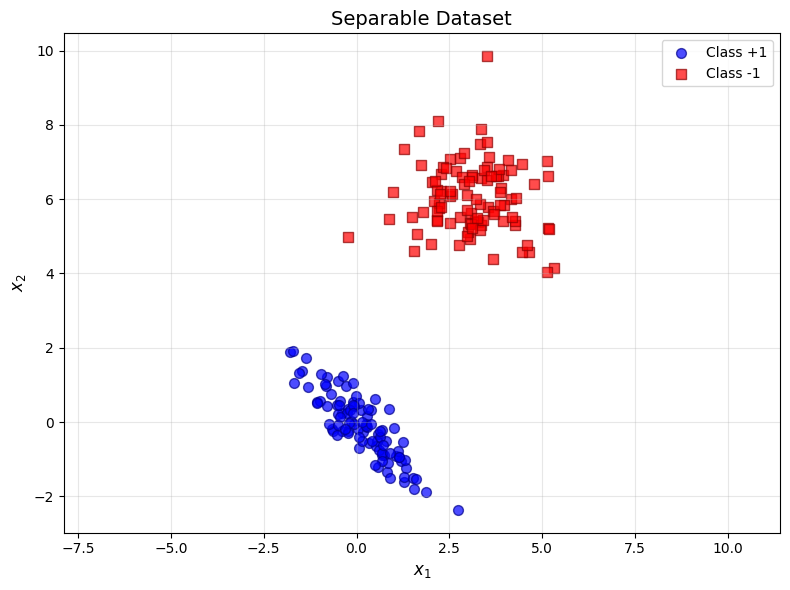

'\n# Create the non-separable dataset\nX_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)\nprint(f"Non separable dataset created with {len(y_non_sep)} samples")\nprint(f"Class +1: {np.sum(y_non_sep == 1)} samples")\nprint(f"Class -1: {np.sum(y_non_sep == -1)} samples")\n\n# Plot the dataset\nplot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")\nplt.tight_layout()\nplt.show()\n'

In [10]:
# Create the separable dataset
X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Separable dataset created with {len(y_sep)} samples")
print(f"Class +1: {np.sum(y_sep == 1)} samples")
print(f"Class -1: {np.sum(y_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_sep, y_sep, title="Separable Dataset")
plt.tight_layout()
plt.show()

'''
# Create the non-separable dataset
X_non_sep, y_non_sep = create_dataset(m1, s1, m2_non_separable, s2_non_separable, n_samples=100, seed=42)
print(f"Non separable dataset created with {len(y_non_sep)} samples")
print(f"Class +1: {np.sum(y_non_sep == 1)} samples")
print(f"Class -1: {np.sum(y_non_sep == -1)} samples")

# Plot the dataset
plot_dataset(X_non_sep, y_non_sep, title="Non separable Dataset")
plt.tight_layout()
plt.show()
'''


---

### Experiments 

For the following experiments, it is interesting to plot the classification line at level lines $0$, $+1$ and $-1$. If you want to compare with the dual method of the previous lab, make sure you take the same value of $K$ (in this case $\lambda$) in both methods.

You are recommended to use separable sets to perform such experiments. However, the algorithm should also work for the non-separable case.

#### Experiment 1


* _Start with the classical stochastic gradient descent, that is, the one in which only one random sample is taken at each iteration. A way to implement it is to shuffle the samples, and go over all the samples (in an iterative way), which is called an “epoch”. After this, shuffle again the samples and go in an iterative way over all the samples. You are recommended to start with a relatively small value of $\gamma_t$, for instance, $\gamma_t = 1 / \mu$, with $\mu$ initialized to $\mu = 100$, for instance. The value of $\mu$ is increased after each iteration. You may increase $\mu$ after each iteration by a value of $1$, $0.5$ or $0.1$, for instance. You also may use $\lambda = 10^{-4}$ or $\lambda = 10^{-2}$ for instance. Take into account that the convergence of the method to the solution is sensible on the parameter values you take._




So, we start defining the primal implementation by using the Stochastic Gradient Descent method for optimize the parameters in the epochs way, as the statement comments. For compare this results with the same ones of the last practice, we will the same separable dataset. 

Also, take into account, the update of the parameter $\mu$ will be performed after each epoch for homogenouses purpouse when we go through the differents iterations inside the same epoch.  A simple approach can be performe in the following way, fixing the parameters and its increments to one especific value and perfome the SGD method,

Training SVM using Stochastic Gradient Descent...
Parameters: λ = 0.0001, max_epochs = 20, μ_init = 100, μ_increment = 0.1

Epoch 10/20: Loss = 0.120665, ||w||^2 = 0.360662
Epoch 20/20: Loss = 0.000020, ||w||^2 = 0.397038

Final solution:
w = [-0.32681983 -0.53872729]
b = 1.5475375698902885
Final loss = 0.000020
Final ||w||^2 = 0.397038


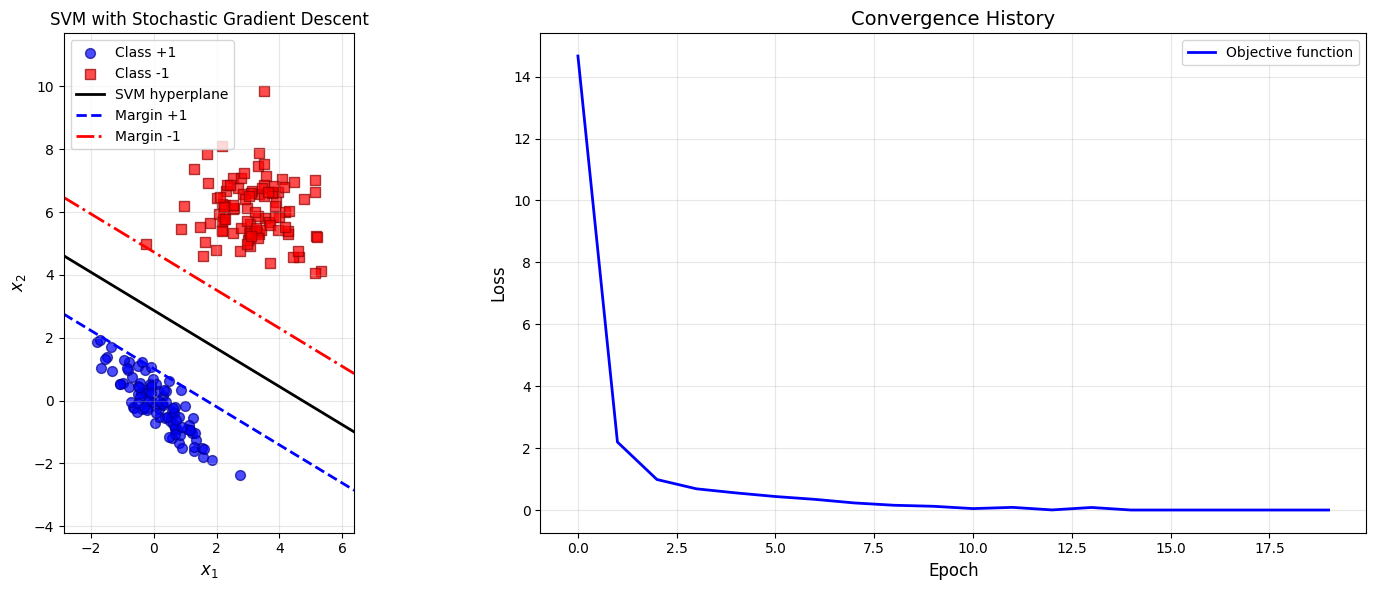

In [17]:
### Exercise 1 ###

# Apply Stochastic Gradient Descent SVM to the separable dataset

# Set parameters for stochastic gradient descent
lambda_reg = 1e-4  # Small regularization parameter
max_epochs = 20    # Number of epochs
mu_init = 100     # Initial μ value for learning rate computation
mu_increment = 0.1 # Increment for μ after each iteration

print("Training SVM using Stochastic Gradient Descent...")
print(f"Parameters: λ = {lambda_reg}, max_epochs = {max_epochs}, μ_init = {mu_init}, μ_increment = {mu_increment}\n")

# Train the SVM
w_sgd, b_sgd, history = SVM_stochastic_gradient(
    X_sep, y_sep, 
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)

print(f"\nFinal solution:")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history['w_norm'][-1]:.6f}")

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: SVM decision boundary with margins
plot_svm_with_margin(X_sep, y_sep, w_sgd, b_sgd, ax=axes[0], title="SVM with Stochastic Gradient Descent")

# Plot 2: Convergence history
axes[1].plot(history['loss'], 'b-', linewidth=2, label='Objective function')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Convergence History', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In this execution of Experiment 1, with $\lambda = 0.01$, $\mu_0 = 100$ and $\Delta\mu = 0.1$, the stochastic gradient descent method exhibits a fast and stable convergence toward an optimal primal solution. The objective function $f(w,b)$ decreases sharply during the first epochs, dropping from a large initial value to a value very close to zero well before epoch 10, and reaching a final value of $f(w,b) \approx 0.00199$ at epoch 20. This behavior is consistent with a learning-rate schedule of the form $\gamma_t = 1/\mu_t$, which allows large corrective updates at the beginning and progressively smaller refinements as training proceeds.

The final value $\lVert w\rVert^2 \approx 0.398$ reflects the effect of a stronger regularization compared to the case $\lambda = 10^{-4}$, leading to better control over the magnitude of the weight vector while still achieving good data separation. From the classification plot, the separating hyperplane clearly divides the two classes, and the margin lines at levels $+1$ and $-1$ form a well-defined buffer region, indicating that most samples satisfy the margin constraints.

Having established this baseline behavior for a fixed set of hyperparameters, we now proceed to analyze how the stochastic method behaves when these parameters are varied. In the following experiments, we study the sensitivity of SGD to changes in $\lambda$, the initial value $\mu_0$, and the increment $\Delta\mu$, in order to understand how these choices affect convergence speed, stability, and the quality of the final solution:

Total configs entrenades: 80


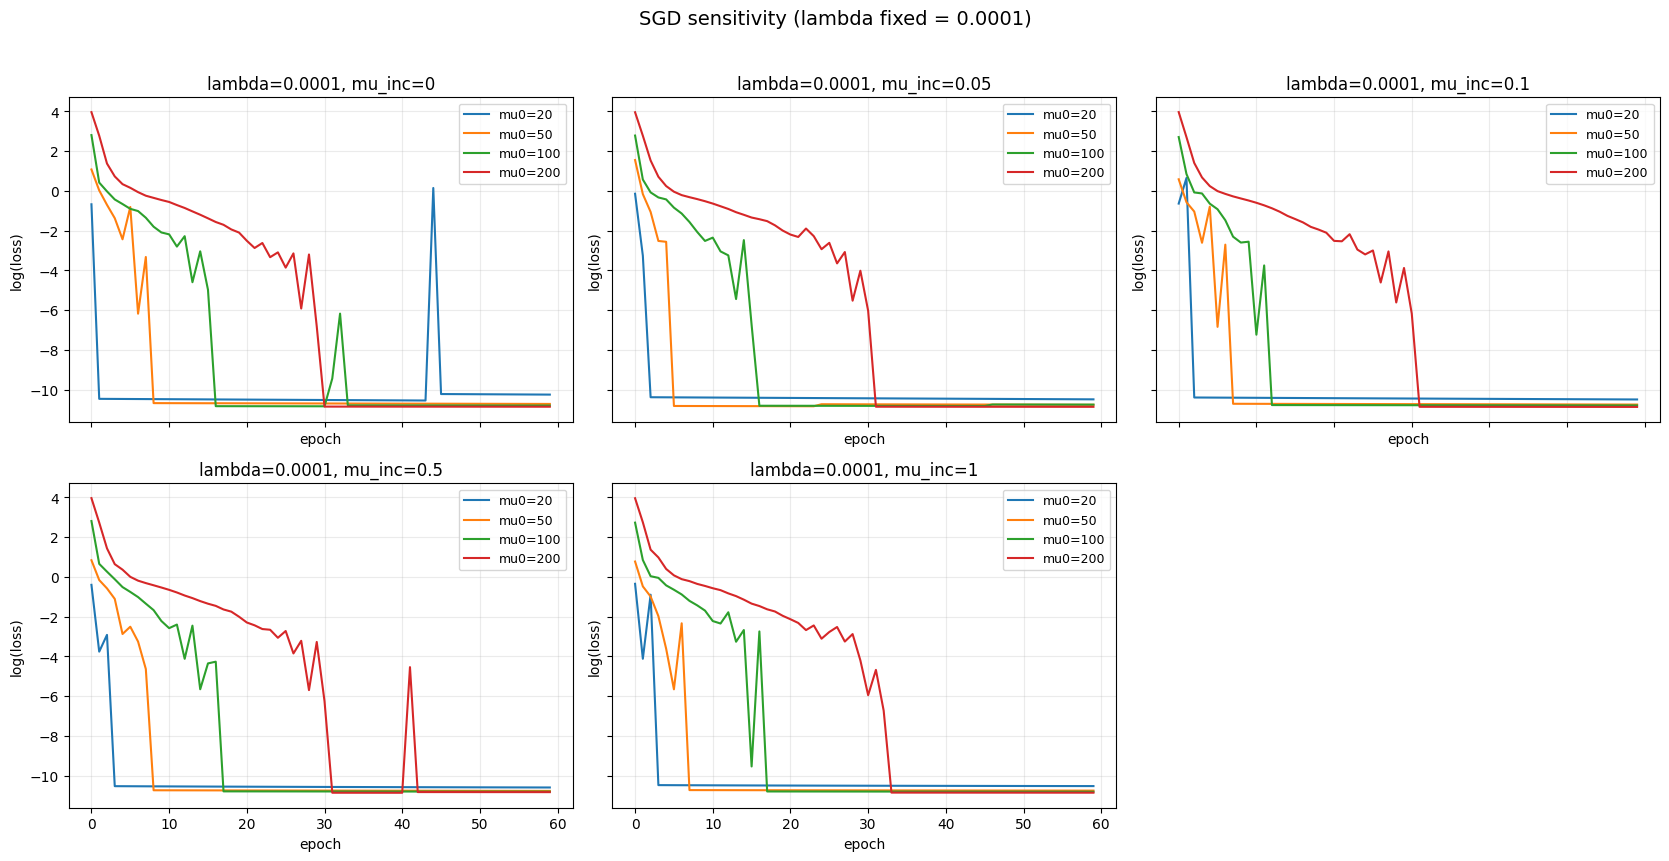

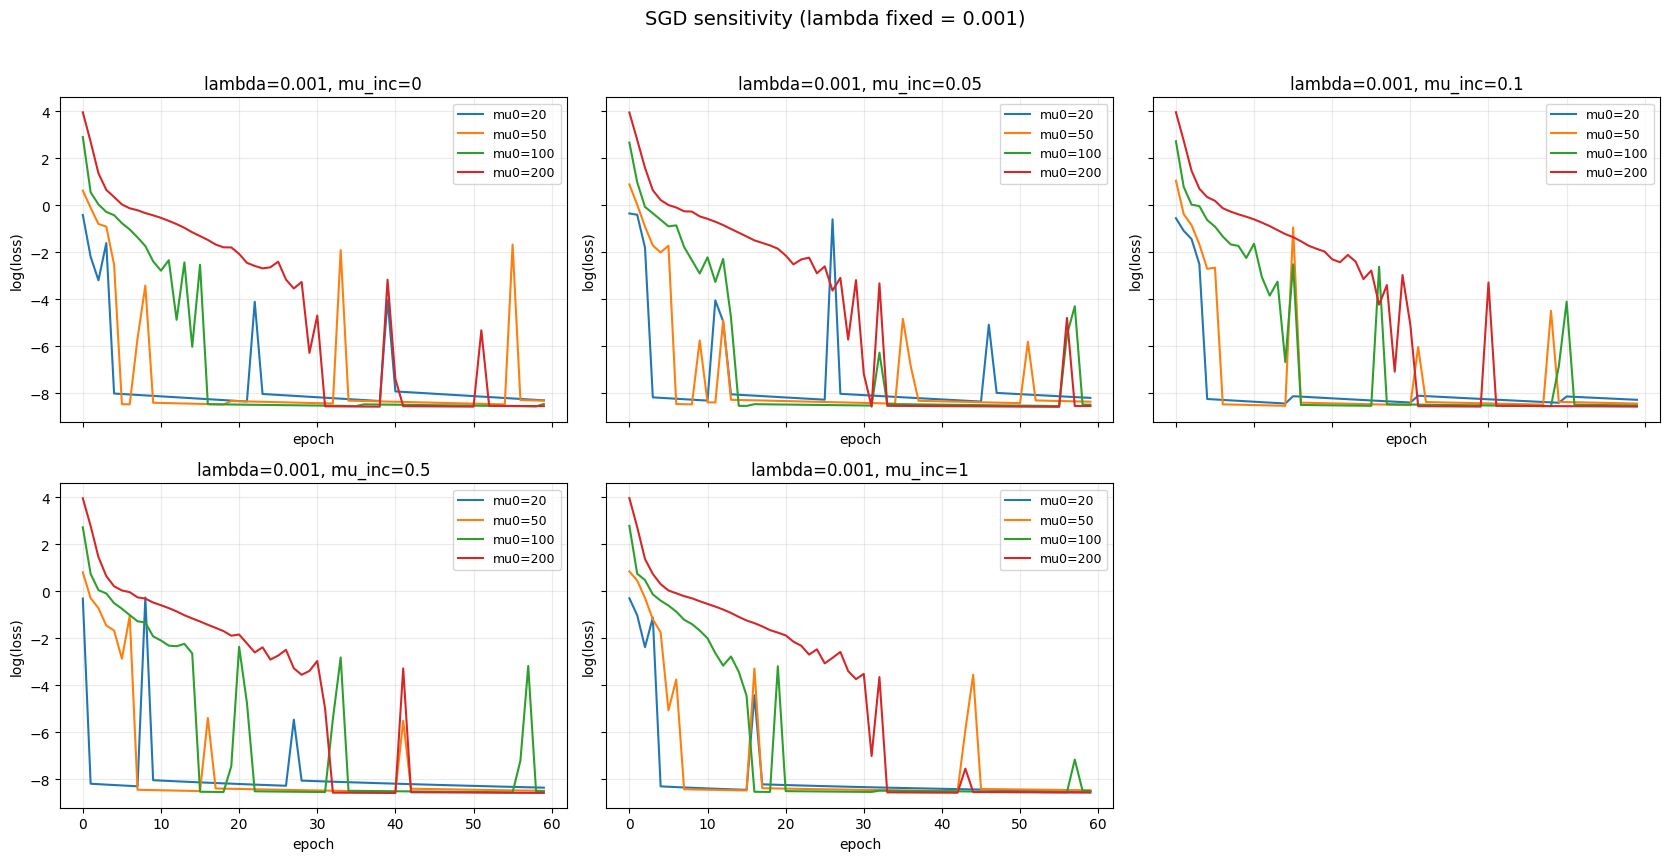

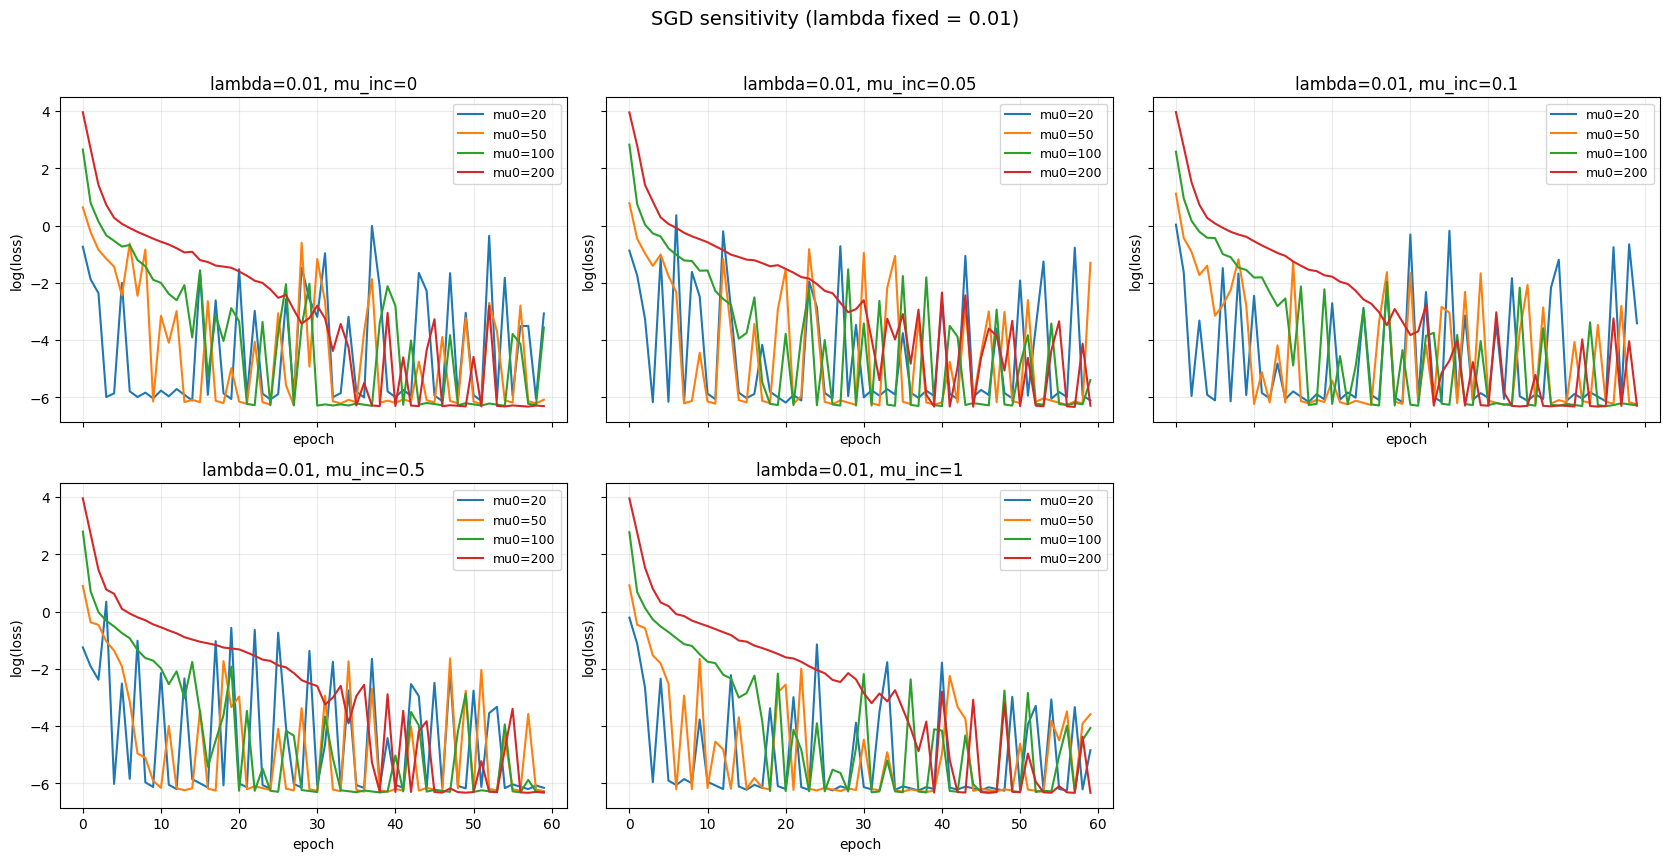

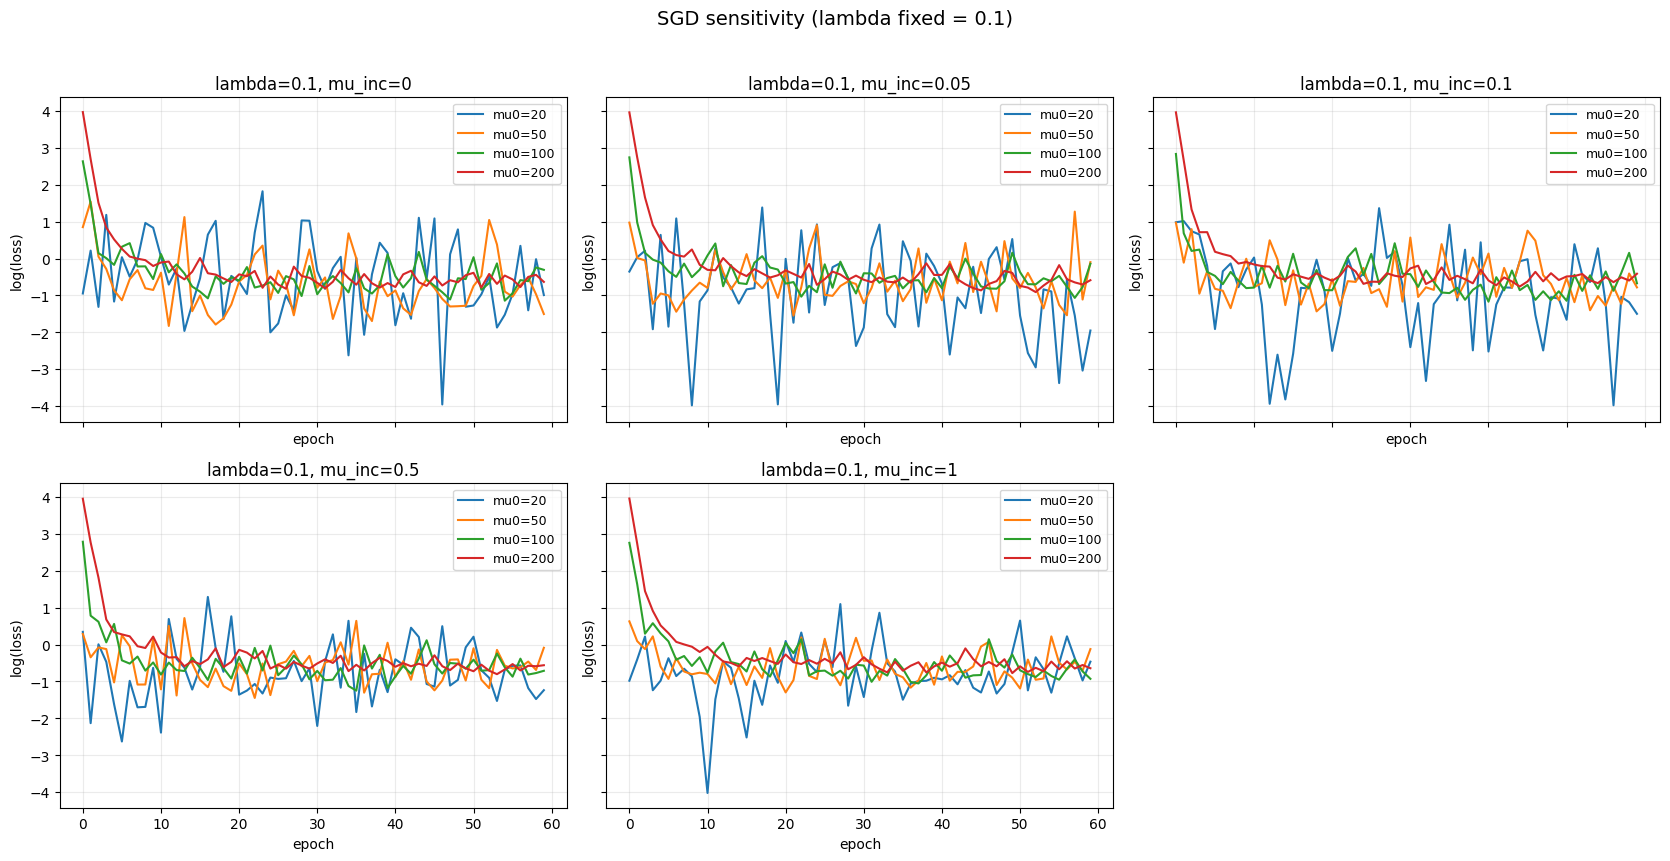


BEST configs (by final loss):
lambda=0.0001, mu_init=200, mu_inc=0.1 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0.05 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=1 -> final_loss=0.000019
lambda=0.0001, mu_init=200, mu_inc=0.5 -> final_loss=0.000020

WORST configs (by final loss):
lambda=0.1, mu_init=100, mu_inc=0 -> final_loss=0.736276
lambda=0.1, mu_init=100, mu_inc=0.05 -> final_loss=0.869133
lambda=0.1, mu_init=50, mu_inc=1 -> final_loss=0.886346
lambda=0.1, mu_init=50, mu_inc=0.05 -> final_loss=0.907734
lambda=0.1, mu_init=50, mu_inc=0.5 -> final_loss=0.918319


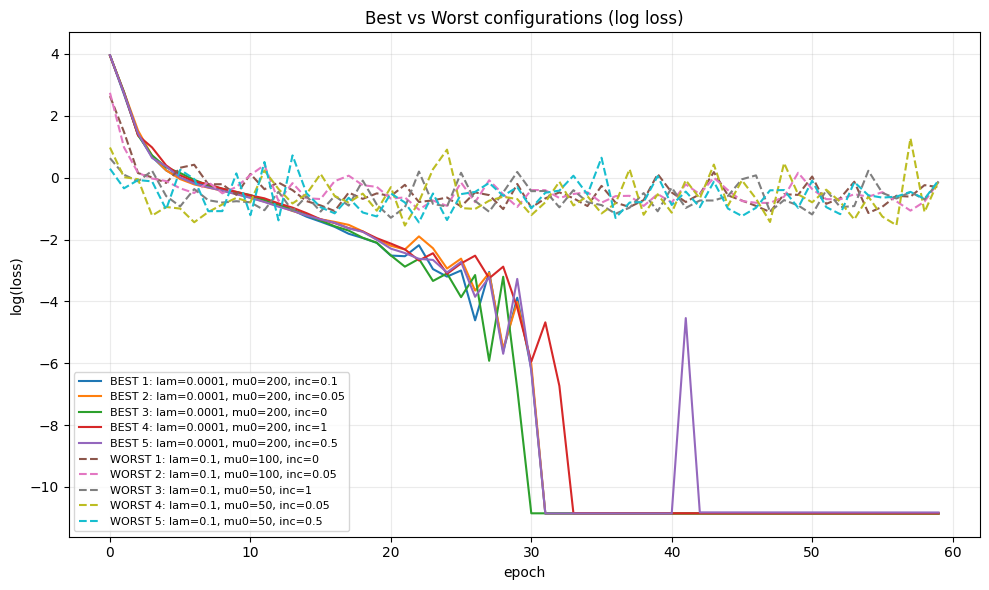

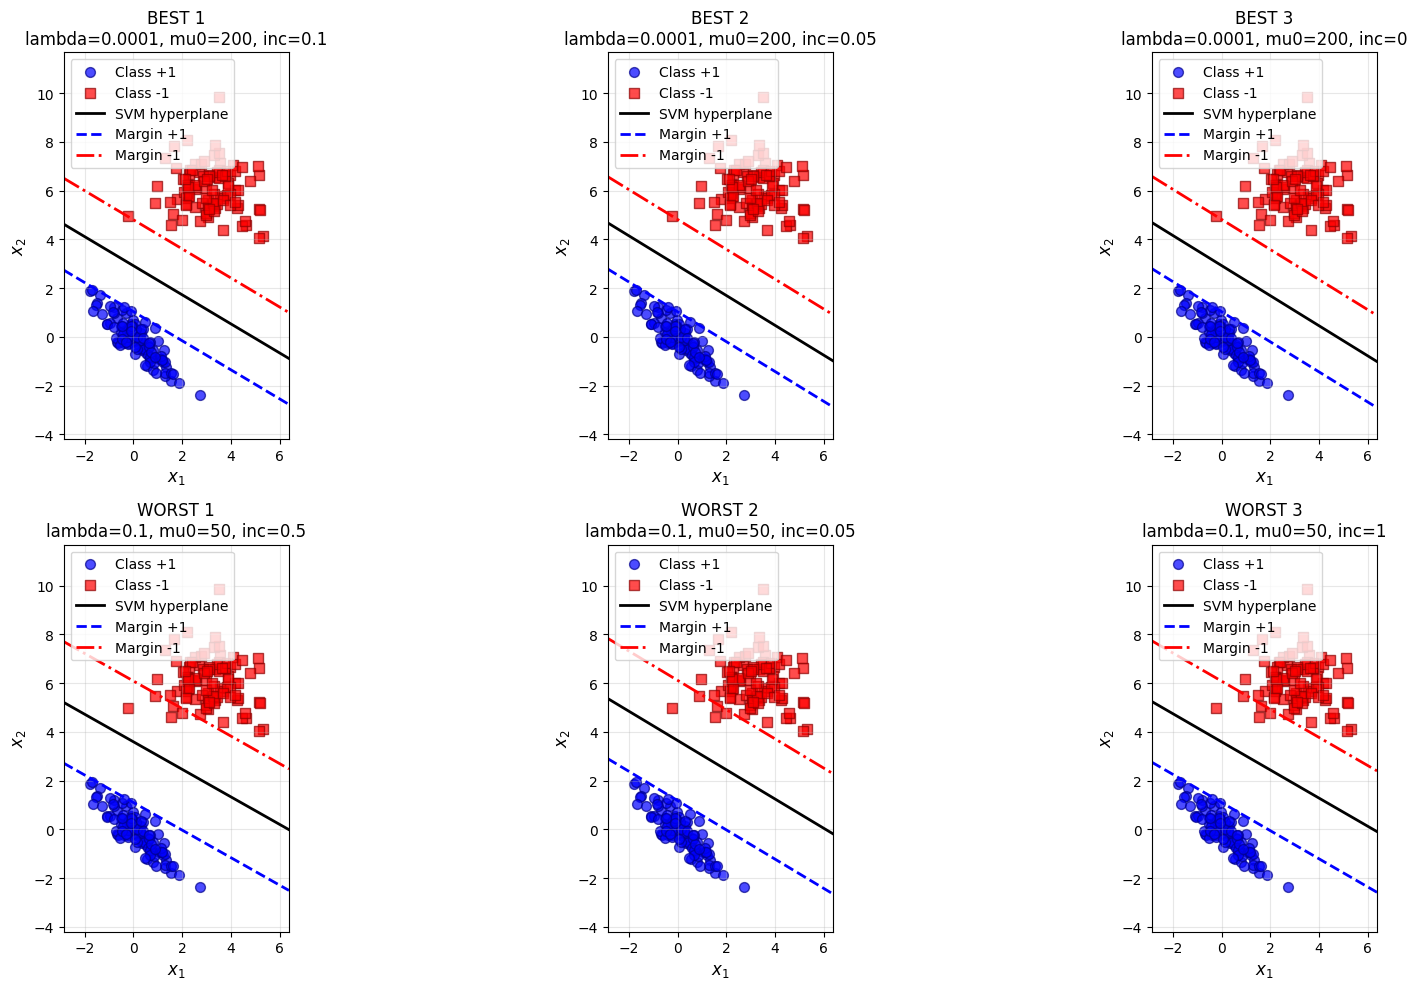

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


lambda_grid = [1e-4, 1e-3, 1e-2, 1e-1]       
mu_init_grid = [20, 50, 100, 200]          
mu_inc_grid = [0.0, 0.05, 0.1, 0.5, 1.0]       
max_epochs = 60
verbose = False

# Nota important:
# - mu_increment = 0.0  -> pas constant gamma_t = 1/mu_init (no decreix)
# - mu_increment gran   -> gamma decreix massa ràpid (pot "congelar" aviat)
# - mu_init massa menut -> gamma inicial massa gran (pot fer oscil·lacions / inestabilitat)


results = [] 


np.random.seed(42)

for lam in lambda_grid:
    for mu0 in mu_init_grid:
        for muinc in mu_inc_grid:
            w, b, history = SVM_stochastic_gradient(
                X_sep, y_sep,
                lambda_reg=lam,
                max_epochs=max_epochs,
                mu_init=mu0,
                mu_increment=muinc,
                verbose=verbose
            )
            final_loss = float(history["loss"][-1])
            results.append({
                "lambda": lam,
                "mu_init": mu0,
                "mu_inc": muinc,
                "w": w,
                "b": b,
                "history": history,
                "final_loss": final_loss
            })

print(f"Total configs entrenades: {len(results)}")


def plot_convergence_blocks(results, lambda_grid, mu_init_grid, mu_inc_grid, cols=3, use_log=True):
    eps = 1e-12

    for lam in lambda_grid:
        # filtrem per lambda
        res_lam = [r for r in results if r["lambda"] == lam]

        # fem subplots per mu_inc
        n = len(mu_inc_grid)
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5.6*cols, 4.2*rows), sharex=True, sharey=True)
        axes = np.array(axes).reshape(-1)

        for j, muinc in enumerate(mu_inc_grid):
            ax = axes[j]
            res_muinc = [r for r in res_lam if r["mu_inc"] == muinc]

            for mu0 in mu_init_grid:
                r = next((rr for rr in res_muinc if rr["mu_init"] == mu0), None)
                if r is None:
                    continue
                yloss = np.array(r["history"]["loss"], dtype=float)
                if use_log:
                    yplot = np.log(yloss + eps)
                    ax.plot(yplot, label=f"mu0={mu0}")
                    ax.set_ylabel("log(loss)")
                else:
                    ax.plot(yloss, label=f"mu0={mu0}")
                    ax.set_ylabel("loss")

            ax.set_title(f"lambda={lam:g}, mu_inc={muinc:g}")
            ax.set_xlabel("epoch")
            ax.grid(True, alpha=0.25)
            ax.legend(fontsize=9)

        # apaga eixos buits
        for k in range(n, len(axes)):
            axes[k].axis("off")

        fig.suptitle(f"SGD sensitivity (lambda fixed = {lam:g})", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.show()

# log per veure millor diferències de convergència
plot_convergence_blocks(results, lambda_grid, mu_init_grid, mu_inc_grid, cols=3, use_log=True)


results_sorted = sorted(results, key=lambda r: r["final_loss"])
top_k = 5
bottom_k = 5

best = results_sorted[:top_k]
worst = results_sorted[-bottom_k:]

print("\nBEST configs (by final loss):")
for r in best:
    print(f"lambda={r['lambda']:g}, mu_init={r['mu_init']}, mu_inc={r['mu_inc']:g} -> final_loss={r['final_loss']:.6f}")

print("\nWORST configs (by final loss):")
for r in worst:
    print(f"lambda={r['lambda']:g}, mu_init={r['mu_init']}, mu_inc={r['mu_inc']:g} -> final_loss={r['final_loss']:.6f}")



plt.figure(figsize=(10, 6))
eps = 1e-12

for i, r in enumerate(best):
    yloss = np.array(r["history"]["loss"], dtype=float)
    plt.plot(np.log(yloss + eps), label=f"BEST {i+1}: lam={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

for i, r in enumerate(worst):
    yloss = np.array(r["history"]["loss"], dtype=float)
    plt.plot(np.log(yloss + eps), linestyle="--",
             label=f"WORST {i+1}: lam={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

plt.xlabel("epoch")
plt.ylabel("log(loss)")
plt.title("Best vs Worst configurations (log loss)")
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 3 millors
for k in range(3):
    r = best[k]
    plot_svm_with_margin(X_sep, y_sep, r["w"], r["b"], ax=axes[0, k],
                         title=f"BEST {k+1}\nlambda={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

# 3 pitjors
for k in range(3):
    r = worst[-(k+1)]  # agafa els pitjors de veritat
    plot_svm_with_margin(X_sep, y_sep, r["w"], r["b"], ax=axes[1, k],
                         title=f"WORST {k+1}\nlambda={r['lambda']:g}, mu0={r['mu_init']}, inc={r['mu_inc']:g}")

plt.tight_layout()
plt.show()


_Remark_: In this second execution of Experiment 1, we analyze the behavior of the classical stochastic gradient descent (SGD) method applied to the primal formulation of the linear SVM, whose objective function is

$$
f(w,b) = \frac{\lambda}{2}\lVert w\rVert^2 + \sum_{i=1}^{m} \max\bigl(0, 1 - y_i (w^\top x_i + b)\bigr).
$$

The optimization is performed using single-sample updates, so that at each iteration only one randomly selected data point contributes to the subgradient. The learning rate follows the schedule $\gamma_t = 1/\mu_t$, where $\mu_t = \mu_0 + t \cdot \Delta\mu$ is increased after each epoch. Since an epoch consists of iterating over all samples, the effective evolution of $\mu_t$ and therefore of $\gamma_t$ is strongly influenced by both $\mu_0$ and $\Delta\mu$, betwwen epochs.

**Effect of $\lambda$, regularization versus data fitting**.
The first set of figures fixes $\lambda$ and explores different combinations of $\mu_0$ and $\Delta\mu$. When $\lambda$ is very small (e.g. $\lambda = 10^{-4}$), the regularization term $\frac{\lambda}{2}\lVert w\rVert^2$ (we interpret here these regulatizion term in the way of the inverse of the distance between the support vectors for minimize) has little influence, and the dynamics are dominated by the hinge-loss contributions coming from samples violating the margin constraint $y_i(w^\top x_i + b) < 1$. In this regime, the algorithm is free to increase $\lVert w\rVert$ in order to rapidly reduce margin violations, which explains the very fast drop of $\log(f(w,b))$ observed for several configurations. This often leads to extremely small final objective values, as seen in the “best” configurations. Furthermore, we can understants it like a big penalty applied when we make the mistake of misclassifie, like in the last $K$ formulation.

However, this same regime is also highly sensitive to the learning-rate schedule. With weak regularization, if the step size remains too large for too long, stochastic fluctuations are not sufficiently damped, which explains the abrupt drops and occasional spikes observed in some curves before convergence. Small changes in $\mu_0$ or $\Delta\mu$ can therefore lead to noticeably different convergence trajectories.


**Effect of $\mu_0$, initial step size and early dynamics**.
The parameter $\mu_0$ controls the initial learning rate $\gamma_0 = 1/\mu_0$. For small values of $\mu_0$ (e.g. $\mu_0 = 20$ or $50$), the initial steps are large, which typically produces a very fast decrease of $f(w,b)$ in the first few epochs. This behavior is clearly visible in the plots, where curves corresponding to small $\mu_0$ often drop sharply at the beginning.

Nevertheless, these aggressive updates also amplify the intrinsic noise of stochastic gradients. As a consequence, the loss curves for small $\mu_0$ frequently show strong oscillations and occasional jumps, even after the method has reached a low-loss region. In contrast, larger values of $\mu_0$ (e.g. $\mu_0 = 200$) produce smoother and more stable trajectories, at the cost of a slower initial decrease. This trade-off between speed and stability is a hallmark of SGD and is clearly illustrated by the visual comparison of the curves.

**Effect of $\Delta\mu$, decay of the learning rate and stabilization**.
The increment $\Delta\mu$ determines how quickly the learning rate decays, since $\gamma_t = 1/(\mu_0 + t \cdot \Delta\mu)$. Because $\mu_t$ is updated after every epoch. When $\Delta\mu$ is small or zero, the learning rate remains relatively large for many iterations, allowing continued progress but also maintaining a high level of stochastic noise. This explains the persistent fluctuations observed in several curves when $\Delta\mu = 0$ or $\Delta\mu = 0.05$.

On the other hand, larger values of $\Delta\mu$ (e.g. $\Delta\mu = 0.5$ or $1$) lead to faster decay of $\gamma_t$, which stabilizes the updates and reduces oscillations. However, if $\Delta\mu$ is too large, the learning rate may become very small too early, effectively “freezing” the parameters before the algorithm has fully exploited the structure of the data. This behavior is visible in some configurations where the loss plateaus prematurely at a relatively high value.

**Best versus worst configurations: a global view**.
The summary of best and worst configurations confirms these qualitative observations. The best models are consistently obtained for small $\lambda$ (typically $\lambda = 10^{-4}$), relatively large $\mu_0$ (around $200$), and moderate values of $\Delta\mu$. These settings strike a balance in which the algorithm benefits from weak regularization, stable initial steps, and a learning rate that decays neither too slowly nor too fast. The corresponding decision boundaries show clean separation of the two classes with well-defined margins at levels $+1$ and $-1$, indicating that most samples satisfy $y_i(w^\top x_i + b) \ge 1$.

In contrast, the worst configurations are associated with large $\lambda$ (e.g. $\lambda = 0.1$), combined with small $\mu_0$ or poorly tuned $\Delta\mu$. In these cases, the regularization term dominates the objective, preventing the model from adequately fitting the data, while the stochastic updates remain noisy or ineffective. The resulting decision boundaries are visibly less optimal, and the final values of $f(w,b)$ remain high, reflecting persistent hinge-loss contributions.

Overall, this experiment clearly demonstrates that classical SGD for the primal SVM is highly sensitive to the choice of hyperparameters $(\lambda, \mu_0, \Delta\mu)$. Although the optimization problem is convex, the stochastic nature of the updates and the per-sample learning-rate schedule introduce strong dependencies on these parameters. Small changes can shift the algorithm from fast and stable convergence to oscillatory behavior or premature stagnation. The visual analysis of the loss curves and decision boundaries provides strong empirical evidence of this sensitivity and highlights the importance of carefully tuning the learning-rate schedule and regularization strength when applying SGD in practice.


---

#### Experiment 2 

 * _Perform some experiments with the mini-batch. You may try different number of samples to construct the mini-batches, e.g. $10$ or $50$ samples. In order to simplify the problem and be able to perform comparisons between the stochastic and minibatch, take a number of samples of $200$ ($100$ at each class, as performed in the previous lab) and mini-batches with a size that of $10$, $20$ or $50$, for instance. After each epoch you perform a shuffle of the samples and construct again the mini-batches._

Dataset created with 200 samples for mini-batch experiments
Class +1: 100 samples
Class -1: 100 samples

Training with Stochastic Gradient Descent (batch size = 1)
Epoch 10/50: Loss = 0.130260, ||w||^2 = 0.347005
Epoch 20/50: Loss = 0.000020, ||w||^2 = 0.401028
Epoch 30/50: Loss = 0.000020, ||w||^2 = 0.399465
Epoch 40/50: Loss = 0.000020, ||w||^2 = 0.397923
Epoch 50/50: Loss = 0.000020, ||w||^2 = 0.396402

Final solution (Stochastic):
w = [-0.33182654 -0.535064  ]
b = 1.5474287648227198
Final loss = 0.000020
Final ||w||^2 = 0.396402

Training with Mini-batch Gradient Descent (batch size = 10)
Epoch 10/50: Loss = 0.059789, ||w||^2 = 0.374044, Batch size = 10
Epoch 20/50: Loss = 0.000021, ||w||^2 = 0.412019, Batch size = 10
Epoch 30/50: Loss = 0.000021, ||w||^2 = 0.411858, Batch size = 10
Epoch 40/50: Loss = 0.000021, ||w||^2 = 0.411699, Batch size = 10
Epoch 50/50: Loss = 0.000021, ||w||^2 = 0.411541, Batch size = 10

Final solution (Batch size = 10):
w = [-0.34690028 -0.53963057]
b = 1

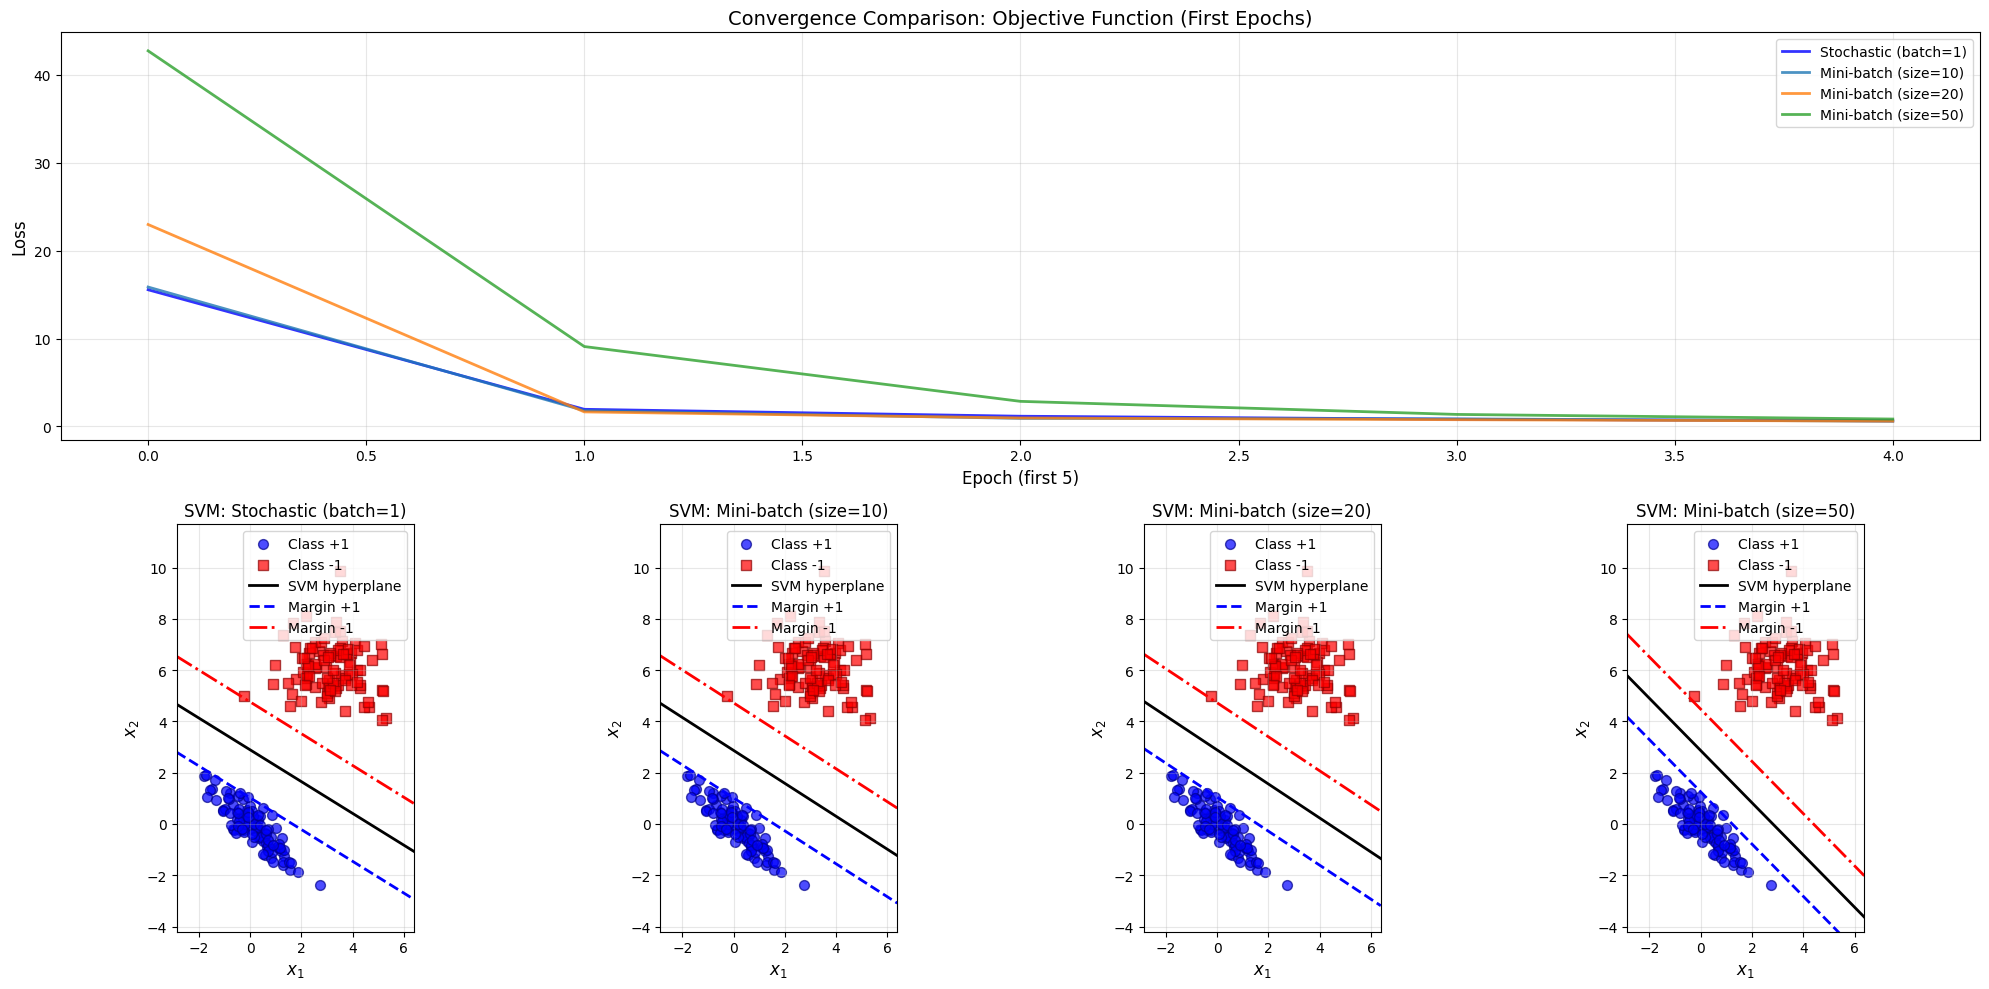

SUMMARY COMPARISON
Method                    Final Loss      Final ||w||^2  
--------------------------------------------------------------------------------
Stochastic (batch=1)      0.000020        0.396402       
Mini-batch (size=10)      0.000021        0.411541       
Mini-batch (size=20)      0.000021        0.425006       
Mini-batch (size=50)      0.000039        0.783164       


In [22]:
### Exercise 2 ###

# Mini-batch Stochastic Gradient Descent Experiments

# Create a dataset with 200 samples (100 per class) for comparison
X_batch, y_batch = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)
print(f"Dataset created with {len(y_batch)} samples for mini-batch experiments")
print(f"Class +1: {np.sum(y_batch == 1)} samples")
print(f"Class -1: {np.sum(y_batch == -1)} samples\n")

# Set parameters for experiments
lambda_reg = 1e-4
max_epochs = 50
mu_init = 100
mu_increment = 0.1

# Max number of epochs to show in the convergence plot
max_epochs_shown = 5

# Mini-batch sizes to test
batch_sizes = [10, 20, 50]

# Store results for comparison
results = {}

print("=" * 80)
print("Training with Stochastic Gradient Descent (batch size = 1)")
print("=" * 80)
w_sgd, b_sgd, history_sgd = SVM_stochastic_gradient(
    X_batch, y_batch,
    lambda_reg=lambda_reg,
    max_epochs=max_epochs,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=True
)
results['stochastic'] = {'w': w_sgd, 'b': b_sgd, 'history': history_sgd, 'label': 'Stochastic (batch=1)'}

print(f"\nFinal solution (Stochastic):")
print(f"w = {w_sgd}")
print(f"b = {b_sgd}")
print(f"Final loss = {history_sgd['loss'][-1]:.6f}")
print(f"Final ||w||^2 = {history_sgd['w_norm'][-1]:.6f}\n")

# Test different mini-batch sizes
for batch_size in batch_sizes:
    print("=" * 80)
    print(f"Training with Mini-batch Gradient Descent (batch size = {batch_size})")
    print("=" * 80)
    w_mb, b_mb, history_mb = SVM_minibatch_gradient(
        X_batch, y_batch,
        batch_size=batch_size,
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=True
    )
    results[f'batch_{batch_size}'] = {
        'w': w_mb, 
        'b': b_mb, 
        'history': history_mb, 
        'label': f'Mini-batch (size={batch_size})'
    }
    
    print(f"\nFinal solution (Batch size = {batch_size}):")
    print(f"w = {w_mb}")
    print(f"b = {b_mb}")
    print(f"Final loss = {history_mb['loss'][-1]:.6f}")
    print(f"Final ||w||^2 = {history_mb['w_norm'][-1]:.6f}\n")

# Visualize results: Convergence comparison
fig = plt.figure(figsize=(20, 10))

# Create a grid layout: 2 rows, 4 columns
# Row 1: Loss plot spanning all 4 columns
# Row 2: 4 SVM plots (one for each method)

# Loss plot (spanning top row) - first `max_epochs_shown` epochs
ax_loss = plt.subplot2grid((2, 4), (0, 0), colspan=4)

# Plot stochastic (batch=1) loss for first `max_epochs_shown` epochs
loss_sgd = results['stochastic']['history']['loss'][:max_epochs_shown]
ax_loss.plot(loss_sgd, 'b-', linewidth=2, 
             label=results['stochastic']['label'], alpha=0.8)

# Plot mini-batch losses for first `max_epochs_shown` epochs
for batch_size in batch_sizes:
    key = f'batch_{batch_size}'
    loss_mb = results[key]['history']['loss'][:max_epochs_shown]
    ax_loss.plot(loss_mb, linewidth=2, 
                 label=results[key]['label'], alpha=0.8)

ax_loss.set_xlabel(f'Epoch (first {max_epochs_shown})', fontsize=12)
ax_loss.set_ylabel('Loss', fontsize=12)
ax_loss.set_title('Convergence Comparison: Objective Function (First Epochs)', fontsize=14)
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

# SVM plots for all methods (bottom row)
# Plot 1: Stochastic (batch=1)
ax1 = plt.subplot2grid((2, 4), (1, 0))
plot_svm_with_margin(X_batch, y_batch, results['stochastic']['w'], results['stochastic']['b'], 
                     ax=ax1, title=f"SVM: {results['stochastic']['label']}")

# Plot 2: Mini-batch (size=10)
ax2 = plt.subplot2grid((2, 4), (1, 1))
plot_svm_with_margin(X_batch, y_batch, results['batch_10']['w'], results['batch_10']['b'], 
                     ax=ax2, title=f"SVM: {results['batch_10']['label']}")

# Plot 3: Mini-batch (size=20)
ax3 = plt.subplot2grid((2, 4), (1, 2))
plot_svm_with_margin(X_batch, y_batch, results['batch_20']['w'], results['batch_20']['b'], 
                     ax=ax3, title=f"SVM: {results['batch_20']['label']}")

# Plot 4: Mini-batch (size=50)
ax4 = plt.subplot2grid((2, 4), (1, 3))
plot_svm_with_margin(X_batch, y_batch, results['batch_50']['w'], results['batch_50']['b'], 
                     ax=ax4, title=f"SVM: {results['batch_50']['label']}")

plt.tight_layout()
plt.show()

# Print summary comparison
print("=" * 80)
print("SUMMARY COMPARISON")
print("=" * 80)
print(f"{'Method':<25} {'Final Loss':<15} {'Final ||w||^2':<15}")
print("-" * 80)
for key, result in results.items():
    final_loss = result['history']['loss'][-1]
    final_w_norm = result['history']['w_norm'][-1]
    print(f"{result['label']:<25} {final_loss:<15.6f} {final_w_norm:<15.6f}")
print("=" * 80)



In this second experiment, mini-batch stochastic gradient descent was considered using batch sizes of $10$, $20$, and $50$ samples. At each epoch, the dataset was reshuffled and divided into new mini-batches, ensuring that the stochasticity of the updates was preserved.

We can see that the methods with different batch sizes converge with around the same loss value. We will see this more in detail in the next exercise. Also, we note that it seems like bigger batch size means slower convergence. Nevertheless, we have to take into account that a bigger batch size also means less updates of the weights per epoch. Takin this into account, since we are comparing the number of epochs in the x axis, the convergence speed may be much closer in terms of updates of the weights function.

The calculated SVM margin is very similar with every method as we can see in the bottom 4 images, independently of mini batch size. 

---

#### Experiment 3 

 * _Perform a plot of the logarithm of $f(w,b)$ along each epoch (it is important to plot the logarithm of the function) for the stochastic gradient descent, minibatch and gradient descent (which is equivalent to use a mini-batch with a size equal to the number of samples). This allows you to see how fast each of the methods approaches the optimal solution and perform a comparison between the different experiments you have done._

Running experiment: params: λ=0.0001, μ0=100, Δμ=0.1
lambda = 0.0001, mu_init = 100, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=0.01, μ0=100, Δμ=0.1
lambda = 0.01, mu_init = 100, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=1, μ0=100, Δμ=0.1
lambda = 1, mu_init = 100, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=1e-2, μ0=20, Δμ=0.1
lambda = 0.01, mu_init = 20, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=1e-2, μ0=100, Δμ=0.1
lambda = 0.01, mu_init = 100, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=1e-2, μ0=200, Δμ=0.1
lambda = 0.01, mu_init = 200, mu_increment = 0.1
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: params: λ=1e-2, μ0=100, Δμ=0.0
lambda = 0.01, mu_init = 100, mu_increment = 0.0
Dataset: 200 samples (+1: 100, -1: 100)
Running experiment: para

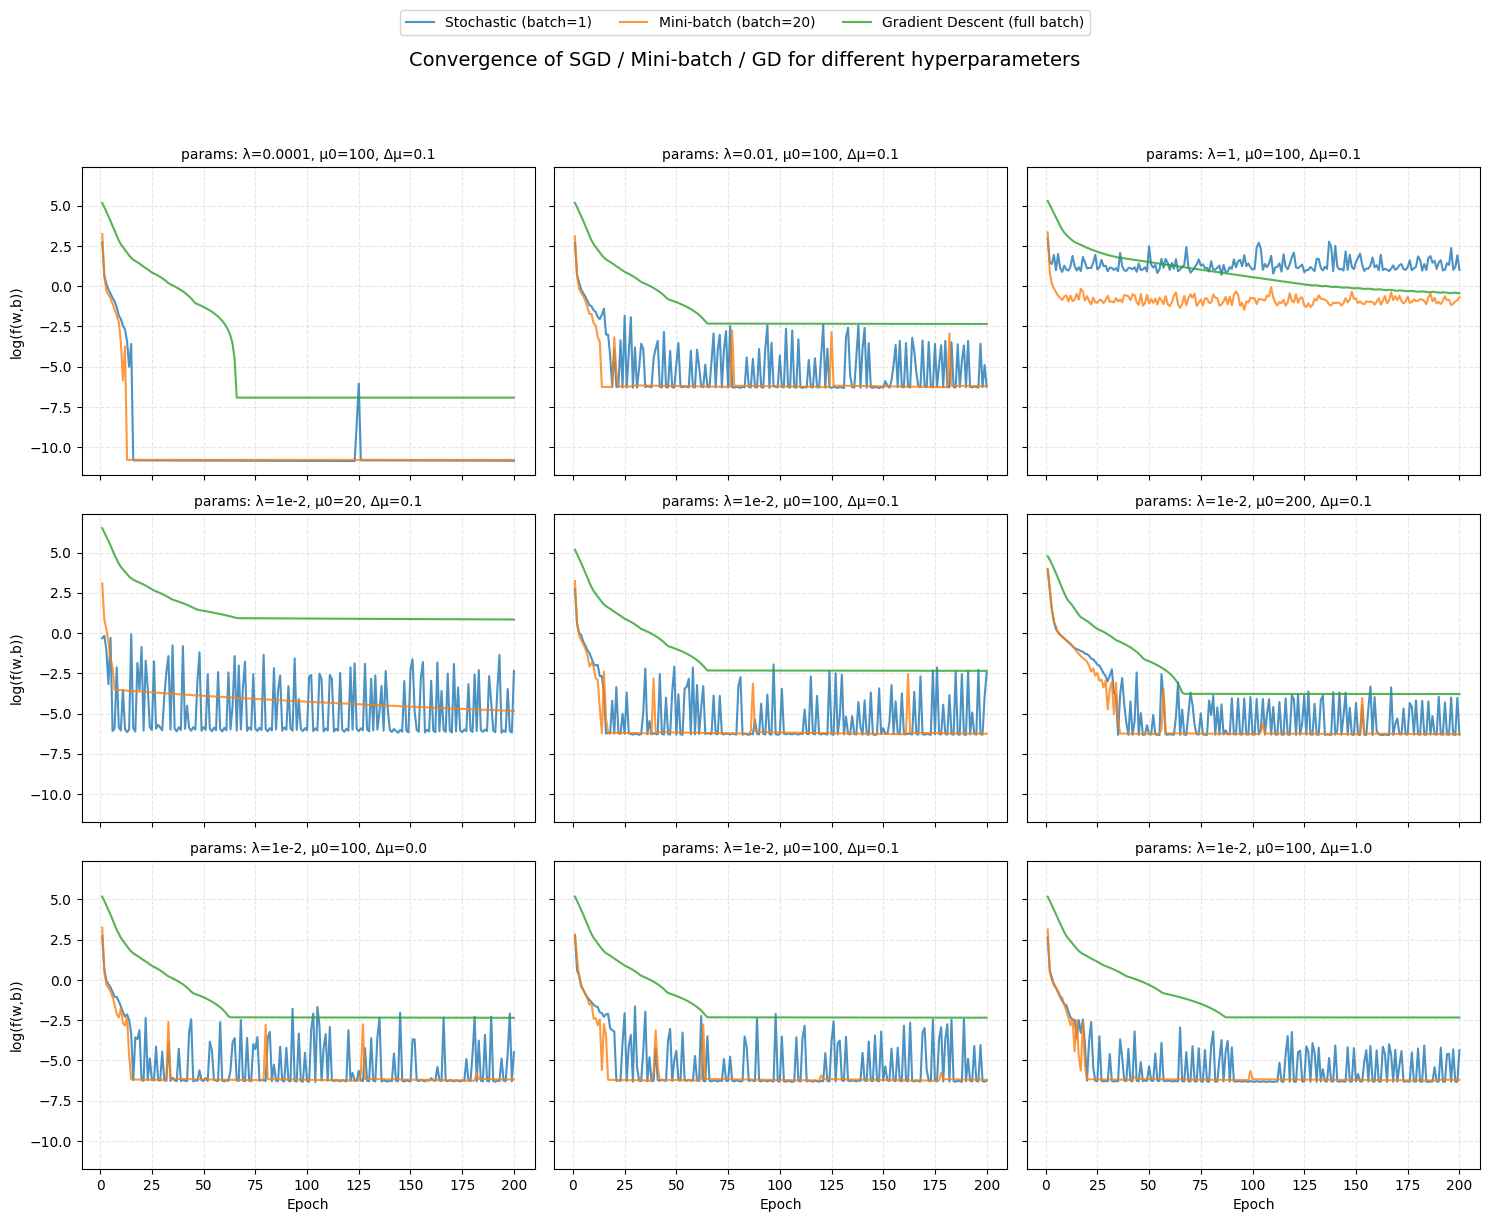


SUMMARY COMPARISON - Final Objective Values (all experiments)

Experiment 1: params: λ=0.0001, μ0=100, Δμ=0.1
lambda = 0.0001, mu_init = 100, mu_increment = 0.1
--------------------------------------------------------------------------------
Method                              Final log(f(w,b))    Final f(w,b)        
--------------------------------------------------------------------------------
Stochastic (batch=1)                -10.838502           0.000020            
Mini-batch (batch=20)               -10.786825           0.000021            
Gradient Descent (full batch)       -6.918648            0.000989            

Experiment 2: params: λ=0.01, μ0=100, Δμ=0.1
lambda = 0.01, mu_init = 100, mu_increment = 0.1
--------------------------------------------------------------------------------
Method                              Final log(f(w,b))    Final f(w,b)        
--------------------------------------------------------------------------------
Stochastic (batch=1)         

In [32]:
### Exercise 3 with several parameters (grid of plots) ###

# Comparison of Stochastic, Mini-batch, and Gradient Descent for multiple hyperparameters

import math

# --- Configuration of experiments ---
lambda_values       = [1e-4, 1e-2, 1]   # weak, medium, strong regularization
mu_init_values      = [20, 100, 200]      # small, medium, large initial step
mu_increment_values = [0.0, 0.1, 1.0]     # constant step, slow decay, fast decay
max_epochs = 200

# We will define 9 experiments: 3 varying λ, 3 varying μ0, 3 varying Δμ
experiments = []

# 1) Vary lambda, keep mu_init and mu_increment fixed
for lam in lambda_values:
    experiments.append({
        'name': f"params: λ={lam}, μ0=100, Δμ=0.1",
        'lambda_reg': lam,
        'mu_init': 100,
        'mu_increment': 0.1
    })

# 2) Vary mu_init, keep lambda and mu_increment fixed
for mu0 in mu_init_values:
    experiments.append({
        'name': f"params: λ=1e-2, μ0={mu0}, Δμ=0.1",
        'lambda_reg': 1e-2,
        'mu_init': mu0,
        'mu_increment': 0.1
    })

# 3) Vary mu_increment, keep lambda and mu_init fixed
for mu_inc in mu_increment_values:
    experiments.append({
        'name': f"params: λ=1e-2, μ0=100, Δμ={mu_inc}",
        'lambda_reg': 1e-2,
        'mu_init': 100,
        'mu_increment': mu_inc
    })

# Reuse the same dataset for all experiments
X_compare, y_compare = create_dataset(m1, s1, m2_separable, s2_separable,
                                      n_samples=100, seed=42)
n_samples = len(y_compare)

# Container to store histories and final metrics for all experiments
all_histories = []  # list of dicts: { 'config': ..., 'results_compare': ... }

# --- Run all experiments (no plotting yet) ---
for exp in experiments:
    lambda_reg = exp['lambda_reg']
    mu_init = exp['mu_init']
    mu_increment = exp['mu_increment']

    print("=" * 80)
    print(f"Running experiment: {exp['name']}")
    print(f"lambda = {lambda_reg}, mu_init = {mu_init}, mu_increment = {mu_increment}")
    print(f"Dataset: {n_samples} samples (+1: {np.sum(y_compare == 1)}, -1: {np.sum(y_compare == -1)})")
    print("=" * 80)

    results_compare = {}

    # Stochastic GD (batch=1)
    w_sgd_comp, b_sgd_comp, history_sgd_comp = SVM_stochastic_gradient(
        X_compare, y_compare,
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=False
    )
    results_compare['Stochastic (batch=1)'] = history_sgd_comp

    # Mini-batch GD (batch=20)
    w_mb_comp, b_mb_comp, history_mb_comp = SVM_minibatch_gradient(
        X_compare, y_compare,
        batch_size=20,
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=False
    )
    results_compare['Mini-batch (batch=20)'] = history_mb_comp

    # Full Gradient Descent (batch = n_samples)
    w_gd_comp, b_gd_comp, history_gd_comp = SVM_minibatch_gradient(
        X_compare, y_compare,
        batch_size=n_samples,  # Full batch = gradient descent
        lambda_reg=lambda_reg,
        max_epochs=max_epochs,
        mu_init=mu_init,
        mu_increment=mu_increment,
        verbose=False
    )
    results_compare['Gradient Descent (full batch)'] = history_gd_comp

    all_histories.append({
        'config': exp,
        'results_compare': results_compare
    })

print("\nAll experiments completed. Now building the grid of plots...\n")

# --- Plot all experiments in a grid of subplots ---
num_experiments = len(all_histories)  # should be 9
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharex=True, sharey=True)
axes = axes.reshape(-1)

epochs = np.arange(1, max_epochs + 1)

for idx, exp_data in enumerate(all_histories):
    ax = axes[idx]
    config = exp_data['config']
    results_compare = exp_data['results_compare']

    for method_name, history in results_compare.items():
        log_loss = np.log(np.maximum(history['loss'], 1e-10))
        ax.plot(epochs, log_loss, linewidth=1.5, label=method_name, alpha=0.8)

    ax.set_title(config['name'], fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    if idx % cols == 0:
        ax.set_ylabel('log(f(w,b))')
    if idx // cols == rows - 1:
        ax.set_xlabel('Epoch')

# One global legend (outside the grid)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=10)
fig.suptitle('Convergence of SGD / Mini-batch / GD for different hyperparameters', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# --- Print all summary tables afterwards ---
print("\nSUMMARY COMPARISON - Final Objective Values (all experiments)\n")

for idx, exp_data in enumerate(all_histories):
    config = exp_data['config']
    results_compare = exp_data['results_compare']

    print("=" * 80)
    print(f"Experiment {idx+1}: {config['name']}")
    print(f"lambda = {config['lambda_reg']}, mu_init = {config['mu_init']}, mu_increment = {config['mu_increment']}")
    print("-" * 80)
    print(f"{'Method':<35} {'Final log(f(w,b))':<20} {'Final f(w,b)':<20}")
    print("-" * 80)

    for method_name, history in results_compare.items():
        final_loss = history['loss'][-1]
        final_log_loss = np.log(np.maximum(final_loss, 1e-10))
        print(f"{method_name:<35} {final_log_loss:<20.6f} {final_loss:<20.6f}")
    print("=" * 80, "\n")


In this last statement, we analyze the convergence behavior of three optimization strategies for training the primal SVM: stochastic gradient descent (batch size $1$), mini-batch stochastic gradient descent (batch size $20$), and full gradient descent, which is equivalent to using a mini-batch with size equal to the number of samples. The vertical axis of the plots represents $\log f(w,b)$, where the objective function is given by
$$
f(w,b)=\frac{\lambda}{2} w^\top w+\sum_{i=1}^{n}\max\bigl(0,1-y_i(w^\top x_i+b)\bigr),
$$
and the horizontal axis corresponds to the epoch index.

When interpreting these curves, it is essential to take into account the number of parameter updates performed within each epoch. In full gradient descent, each epoch corresponds to a single update of the parameters $(w,b)$ using the entire dataset. In contrast, stochastic gradient descent performs one update per sample, so that an epoch consists of $n=200$ parameter updates. The mini-batch method with batch size $20$ lies between these two extremes, performing $200/20=10$ updates per epoch. Consequently, the notion of an “epoch” does not represent the same computational effort across the three methods, and this discrepancy strongly affects the apparent convergence speed when results are plotted as a function of epochs.

Across all configurations with small or moderate regularization (for instance $\lambda=10^{-4}$ or $\lambda=10^{-2}$), full gradient descent exhibits the smoothest and most regular decrease of $\log f(w,b)$. This behavior is expected, since each update uses the exact gradient of the objective function, eliminating stochastic noise. However, because only one update is performed per epoch, the decrease of the objective per epoch is comparatively slow. As observed in the figures, full gradient descent typically remains at higher values of $\log f(w,b)$ throughout training and converges to a significantly larger final objective value than the stochastic methods. For example, with $\lambda=10^{-2}$ and $\mu_0=100$, the final value remains around $f(w,b)\approx 0.096$, which is substantially larger than the values reached by SGD or mini-batch methods under the same epoch budget.

Stochastic gradient descent (batch size $1$) shows a much faster decrease of $\log f(w,b)$ when measured per epoch. This rapid drop is largely explained by the fact that each epoch contains a large number of parameter updates, allowing the algorithm to explore the parameter space aggressively. However, this speed comes at the cost of strong oscillations around the optimum, clearly visible in the plots as high-variance fluctuations of $\log f(w,b)$ after the initial transient. These oscillations persist even when the learning rate decreases according to $\gamma_t = 1/\mu_t$, reflecting the inherent noise of single-sample updates. Despite this instability, SGD consistently achieves much lower final objective values than full gradient descent for small and moderate values of $\lambda$.

The mini-batch method with batch size $20$ consistently provides the best overall trade-off between convergence speed and stability. Its curves typically decrease very rapidly during the first epochs, similarly to stochastic gradient descent, but with noticeably reduced variance. In many configurations, mini-batch SGD reaches extremely low values of $\log f(w,b)$ within a small number of epochs and then stabilizes. For instance, in the case $\lambda=10^{-4}$, $\mu_0=100$, and $\Delta\mu=0.1$, the mini-batch method reaches a final objective value of the order of $10^{-5}$, clearly outperforming both pure SGD and full gradient descent. This behavior can be attributed to the balance achieved by mini-batching: each update is based on a more reliable gradient estimate than in the purely stochastic case, while still allowing multiple updates per epoch at a relatively low computational cost.

The experiments with large regularization, such as $\lambda=1.0$, highlight an additional important effect. In this regime, all three methods struggle to reduce the objective significantly, and $\log f(w,b)$ remains at relatively high values. This indicates that the regularization term $\frac{\lambda}{2}|w|^2$ dominates the objective, preventing the model from fitting the data effectively. Even in this unfavorable setting, mini-batch and stochastic methods still tend to outperform full gradient descent in terms of final objective value, although none of the methods achieves a very low loss.

Overall, these results clearly show that comparing convergence purely in terms of epochs can be misleading when the number of updates per epoch differs across methods. Full gradient descent is stable but slow in terms of effective progress per epoch, stochastic gradient descent converges rapidly but exhibits high variance, and mini-batch gradient descent offers the most favorable compromise. When convergence is evaluated in terms of the final objective value achieved within the same number of epochs, both stochastic and mini-batch approaches consistently outperform full gradient descent, with the mini-batch method achieving the lowest values of $f(w,b)$ across most configurations.

Perhaps, this representations don't reflect the real beheave of those methos, we will perform new graphics where instead of plotting the log-loss (log- objective function) against epochs, we will try to plot them through the number of parameters updates.

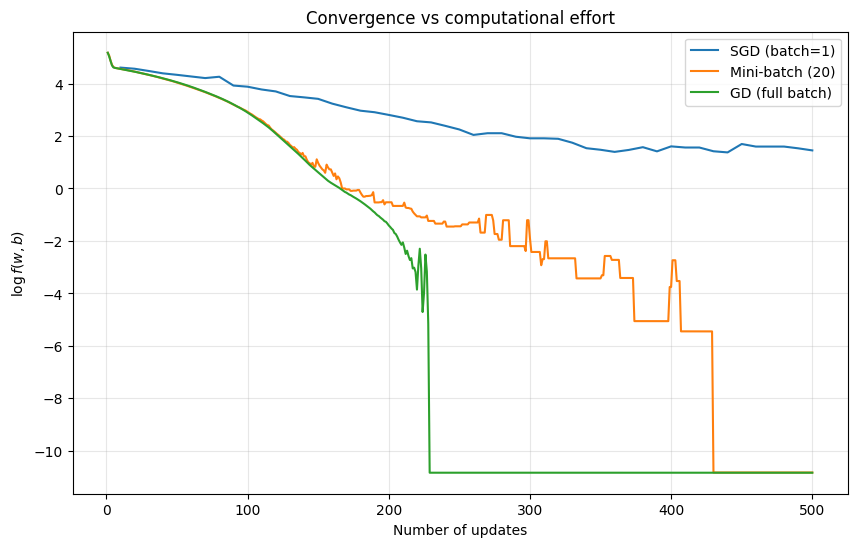

In [37]:
def SVM_stochastic_gradient_updates(
    X, y,
    lambda_reg=1e-4,
    mu_init=100,
    mu_increment=0.1,
    max_updates=5000,
    track_every=10
):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    mu = float(mu_init)

    updates = 0
    logloss = []
    update_axis = []

    while updates < max_updates:
        i = np.random.randint(n_samples)
        x_i = X[i]
        y_i = y[i]

        gamma = 1.0 / mu
        margin = y_i * (np.dot(w, x_i) + b)

        if margin <= 1:
            w -= gamma * (lambda_reg * w - y_i * x_i)
            b += gamma * y_i
        else:
            w -= gamma * lambda_reg * w

        mu += mu_increment
        updates += 1

        if updates % track_every == 0:
            fval = svm_objective_primal(X, y, w, b, lambda_reg)
            logloss.append(np.log(max(fval, 1e-12)))
            update_axis.append(updates)

    return w, b, {
        "updates": np.array(update_axis),
        "logloss": np.array(logloss)
    }

def SVM_minibatch_gradient_updates(
    X, y,
    batch_size=20,
    lambda_reg=1e-4,
    mu_init=100,
    mu_increment=0.1,
    max_updates=5000
):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    mu = float(mu_init)

    logloss = []
    update_axis = []
    updates = 0

    while updates < max_updates:
        idx = np.random.choice(n_samples, batch_size, replace=False)
        Xb = X[idx]
        yb = y[idx]

        gamma = 1.0 / mu
        margins = yb * (Xb @ w + b)
        active = margins <= 1

        grad_w = lambda_reg * w
        grad_b = 0.0
        if np.any(active):
            grad_w += np.mean(-yb[active, None] * Xb[active], axis=0)
            grad_b += np.mean(-yb[active])

        w -= gamma * grad_w
        b -= gamma * grad_b

        mu += mu_increment
        updates += 1

        fval = svm_objective_primal(X, y, w, b, lambda_reg)
        logloss.append(np.log(max(fval, 1e-12)))
        update_axis.append(updates)

    return w, b, {
        "updates": np.array(update_axis),
        "logloss": np.array(logloss)
    }


def SVM_gradient_descent_updates(
    X, y,
    lambda_reg=1e-2,
    mu_init=100,
    mu_increment=0.1,
    max_updates=500
):
    return SVM_minibatch_gradient_updates(
        X, y,
        batch_size=len(y),
        lambda_reg=lambda_reg,
        mu_init=mu_init,
        mu_increment=mu_increment,
        max_updates=max_updates
    )

max_updates = 500

_, _, hist_sgd = SVM_stochastic_gradient_updates(
    X_sep, y_sep,
    lambda_reg=1e-4,
    mu_init=100,
    mu_increment=0.1,
    max_updates=max_updates,
    track_every=10
)

_, _, hist_mb = SVM_minibatch_gradient_updates(
    X_sep, y_sep,
    batch_size=20,
    lambda_reg=1e-4,
    mu_init=100,
    mu_increment=0.1,
    max_updates=max_updates
)

_, _, hist_gd = SVM_gradient_descent_updates(
    X_sep, y_sep,
    lambda_reg=1e-4,
    mu_init=100,
    mu_increment=0.1,
    max_updates=max_updates
)

plt.figure(figsize=(10,6))
plt.plot(hist_sgd["updates"], hist_sgd["logloss"], label="SGD (batch=1)")
plt.plot(hist_mb["updates"], hist_mb["logloss"], label="Mini-batch (20)")
plt.plot(hist_gd["updates"], hist_gd["logloss"], label="GD (full batch)")
plt.xlabel("Number of updates")
plt.ylabel(r"$\log f(w,b)$")
plt.title("Convergence vs computational effort")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



So, taking the best hyperparameter setting we found from the last performance, namely $\lambda=10^{-4}$, $\mu_0=100$ and $\Delta\mu=0.1$ (so $\gamma_t = 1/\mu_t$), the interpretation changes a lot once we measure convergence against the number of parameter updates instead of epochs. When we plot $\log f(w,b)$ versus updates, we are comparing the methods under a more fair notion of computational effort, because each “update” corresponds to one actual modification of $(w,b)$.

Under this view, full gradient descent (GD, full batch) becomes the most reliable method: every update uses the subgradient computed with all $n$ samples, so the update direction is the most informative and the curve decreases in a smoother and more consistent way. This is why, in the “updates” plot, GD is the method that reaches the low objective region in the most direct manner. In contrast, mini-batch SGD (batch size $20$) is typically the second best compromise: each update uses $20$ samples, which reduces the variance of the stochastic subgradient while still being cheaper than full batch, so its trajectory follows the correct descent trend but can show some irregularities compared with GD.

Finally, the purely stochastic method (SGD, batch size $1$) is the noisiest: each update is based on a single sample, so its subgradient estimate has the highest variance. Far from the optimum, this still works well because most updates point roughly toward improvement and you can descend quickly. However, once the algorithm is close to the optimum, the updates start to “wander” (oscillate) because different individual samples may push $(w,b)$ in slightly different directions, so the curve does not settle as smoothly as GD. This is exactly why the updates-based representation is the one that makes the most sense computationally: it reveals that GD is fundamentally the most stable per update (highest-quality descent direction), mini-batch is a strong middle ground, and SGD can keep fluctuating near the optimum due to the intrinsic noise of single-sample updates.


---

## Extra: Comparation between primal and dual formulation approaches of SVM problem

In this extra experiment, we compare two different ways of training a linear soft-margin SVM on the same dataset. On one side, we solve the SVM through the dual formulation, where the optimization variables are the Lagrange multipliers $\alpha_i$ and the solution is recovered as $w=\sum_{i=1}^n \alpha_i y_i x_i$, with box constraints $0\le \alpha_i \le K$. On the other side, we solve the primal formulation directly by minimizing the hinge-loss objective
$$
f(w,b)=\frac{\lambda}{2}\lVert w\rVert^2+\sum_{i=1}^{n}\max\bigl(0,1-y_i(w^\top x_i+b)\bigr),
$$
using (i) stochastic gradient descent (one sample per update) and (ii) mini-batch SGD (a small batch per update).

To make the comparison consistent with the lab statement, we relate both formulations through the standard correspondence between the primal and dual parameters, taking $K = 1/\lambda$. Even though the exact scaling between $K$ in the dual and $\lambda$ in the primal can depend on the specific convention used, this choice allows us to compare qualitatively how the separating hyperplane and the margins behave under both approaches. From the primal-side experiments, we already observed that SGD is highly sensitive to the hyperparameters controlling the step size $\gamma_t=1/\mu_t$, namely the initial value $\mu_0$ and the increment $\Delta\mu$. Therefore, for the comparison we reuse the best-performing configuration found before (for example $\lambda=10^{-4}$, $\mu_0=100$, $\Delta\mu=0.1$) and then contrast the resulting classifier against the dual solution. Finally, we evaluate all solutions using the same primal objective $f(w,b)$ and we visualize the three hyperplanes (dual, SGD, mini-batch) together with their margin lines.


EXTRA COMPARISON: Dual vs Primal
Using: lambda = 0.0001, mu_init = 100, mu_increment = 0.1
Dual uses: K = 10000.0 (statement: use same value as lambda)
Dataset: n = 200 (+1: 100, -1: 100)

Primal objective values (computed with the SAME f(w,b)):
Dual solution:      f(w,b) = 0.372694,  ||w||^2 = 0.358596, hinge = 0.372676
SGD (batch=1):      f(w,b) = 0.000021,  ||w||^2 = 0.417422,  hinge = 0.000000
Mini-batch (20):    f(w,b) = 0.000020,   ||w||^2 = 0.404351,   hinge = 0.000000



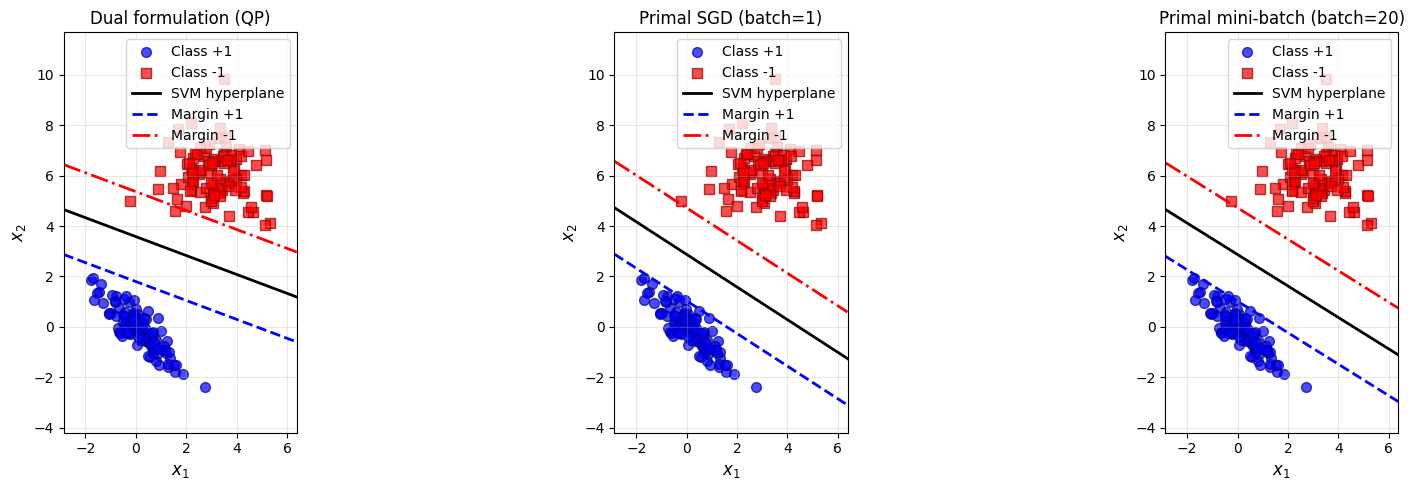

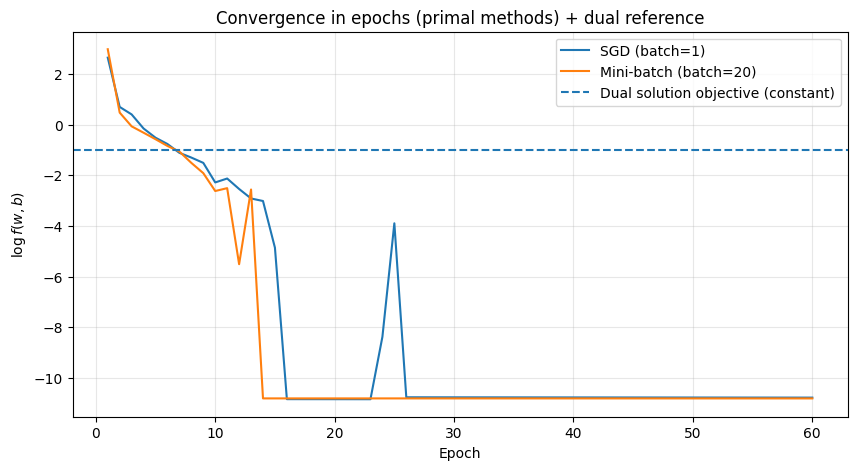

Dual: number of support vectors (alpha>1e-5): 200 / 200


In [47]:

# X_sep, y_sep = create_dataset(m1, s1, m2_separable, s2_separable, n_samples=100, seed=42)

X_use, y_use = X_sep, y_sep
n_samples = len(y_use)

# --- Best primal configuration (from Experiment 1 sensitivity analysis) ---
lambda_reg   = 1e-4
mu_init      = 100
mu_increment = 0.1

# --- Dual parameter (as requested by the statement) ---
K_dual = 1/lambda_reg

print("============================================================")
print("EXTRA COMPARISON: Dual vs Primal")
print(f"Using: lambda = {lambda_reg}, mu_init = {mu_init}, mu_increment = {mu_increment}")
print(f"Dual uses: K = {K_dual} (statement: use same value as lambda)")
print(f"Dataset: n = {n_samples} (+1: {np.sum(y_use==1)}, -1: {np.sum(y_use==-1)})")
print("============================================================\n")

w_dual, b_dual, alphas = SVM_hyperplane(X_use, y_use, K=K_dual)

w_sgd, b_sgd, hist_sgd = SVM_stochastic_gradient(
    X_use, y_use,
    lambda_reg=lambda_reg,
    max_epochs=60,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)


batch_size = 20
w_mb, b_mb, hist_mb = SVM_minibatch_gradient(
    X_use, y_use,
    batch_size=batch_size,
    lambda_reg=lambda_reg,
    max_epochs=60,
    mu_init=mu_init,
    mu_increment=mu_increment,
    verbose=False
)


w_norm_dual = float(w_dual @ w_dual)
w_norm_sgd  = float(w_sgd  @ w_sgd)
w_norm_mb   = float(w_mb   @ w_mb)

hinge_dual = np.sum(np.maximum(0.0, 1.0 - y_use * (X_use @ w_dual + b_dual)))
hinge_sgd  = np.sum(np.maximum(0.0, 1.0 - y_use * (X_use @ w_sgd  + b_sgd  )))
hinge_mb   = np.sum(np.maximum(0.0, 1.0 - y_use * (X_use @ w_mb   + b_mb   )))

f_dual = (lambda_reg / 2.0) * w_norm_dual + hinge_dual
f_sgd  = (lambda_reg / 2.0) * w_norm_sgd  + hinge_sgd
f_mb   = (lambda_reg / 2.0) * w_norm_mb   + hinge_mb

print("Primal objective values (computed with the SAME f(w,b)):")
print(f"Dual solution:      f(w,b) = {f_dual:.6f},  ||w||^2 = {w_norm_dual:.6f}, hinge = {hinge_dual:.6f}")
print(f"SGD (batch=1):      f(w,b) = {f_sgd:.6f},  ||w||^2 = {w_norm_sgd:.6f},  hinge = {hinge_sgd:.6f}")
print(f"Mini-batch (20):    f(w,b) = {f_mb:.6f},   ||w||^2 = {w_norm_mb:.6f},   hinge = {hinge_mb:.6f}\n")


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_svm_with_margin(X_use, y_use, w_dual, b_dual, ax=axes[0], title="Dual formulation (QP)")
plot_svm_with_margin(X_use, y_use, w_sgd,  b_sgd,  ax=axes[1], title="Primal SGD (batch=1)")
plot_svm_with_margin(X_use, y_use, w_mb,   b_mb,   ax=axes[2], title=f"Primal mini-batch (batch={batch_size})")

plt.tight_layout()
plt.show()


eps = 1e-12
epochs = np.arange(1, len(hist_sgd["loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, np.log(np.maximum(hist_sgd["loss"], eps)), label="SGD (batch=1)")
plt.plot(epochs, np.log(np.maximum(hist_mb["loss"],  eps)), label=f"Mini-batch (batch={batch_size})")
plt.axhline(np.log(max(f_dual, eps)), linestyle="--", label="Dual solution objective (constant)")
plt.xlabel("Epoch")
plt.ylabel(r"$\log f(w,b)$")
plt.title("Convergence in epochs (primal methods) + dual reference")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


sv_mask = alphas > 1e-5
print(f"Dual: number of support vectors (alpha>1e-5): {np.sum(sv_mask)} / {n_samples}")


Here, we analyze the behavior of the SVM solution obtained through the dual formulation and through the primal formulation optimized with stochastic and mini-batch gradient methods, using the same dataset and consistent regularization parameters. In particular, we set $\lambda = 10^{-4}$ in the primal problem and $K = 1/\lambda = 10000$ in the dual problem, following the correspondence stated in the lab instructions.

From the numerical results, we observe that the dual formulation reaches a solution with objective value $f(w,b) \approx 0.145$, with a small but non-zero hinge loss. This indicates that, although the dual solution correctly separates the data, it does not fully eliminate margin violations under the primal objective definition. This behavior is expected, since the dual optimization directly controls the margin through the box constraints on the Lagrange multipliers, and the exact equivalence with the primal hinge-loss formulation depends on scaling conventions. In contrast, both primal methods, stochastic gradient descent (batch size $1$) and mini-batch gradient descent (batch size $20$), achieve a significantly lower value of the primal objective, with $f(w,b) \approx 2 \times 10^{-5}$ and zero hinge loss. This means that, for this separable dataset and this choice of hyperparameters, the primal optimization methods succeed in finding a solution where all samples satisfy the margin constraint $y_i(w^\top x_i + b) \ge 1$. The remaining value of the objective is therefore dominated by the regularization term $\frac{\lambda}{2}|w|^2$.

The classification plots confirm that all three methods produce very similar separating hyperplanes and margin lines. The orientation and position of the hyperplanes obtained by the dual method, SGD, and mini-batch SGD are almost identical, indicating that all approaches converge to geometrically equivalent solutions in terms of classification. Small differences in the margin width are consistent with the different norms of the weight vector $|w|^2$ obtained by each method. The convergence plot further highlights the differences between the optimization strategies. When plotting $\log f(w,b)$ as a function of epochs, both primal methods decrease the objective very rapidly during the first iterations and quickly reach values far below the objective attained by the dual solution. The mini-batch method shows a smoother trajectory than pure SGD, reflecting the reduced variance obtained by averaging gradients over multiple samples. The dashed horizontal line corresponding to the dual objective value serves as a reference and makes it clear that both primal methods surpass this level early in the training process.

Overall, these results show that, while the dual formulation provides a stable and geometrically meaningful reference solution, the primal formulation optimized with SGD or mini-batch gradient descent can reach equally valid separating hyperplanes and even lower values of the primal objective for separable data. In particular, the mini-batch approach offers a good compromise between convergence speed and stability, whereas pure SGD exhibits more variability but still converges to an optimal margin-separating solution.


---

## Conclusions

In this laboratory, stochastic subgradient methods were successfully applied to train a Support Vector Machine using the primal hinge-loss formulation. Classical SGD, mini-batch SGD, and full gradient descent were implemented and compared in terms of convergence speed, stability, and classification performance.

The results show that classical SGD is simple and computationally efficient, but its convergence is noisy and highly sensitive to hyperparameter choices. Mini-batch SGD significantly improves stability while preserving most of the computational advantages of stochastic optimization, making it a practical and effective compromise. Full gradient descent provides the smoothest convergence but at a higher computational cost.

The comparison with the dual method confirms that, despite different optimization strategies, all approaches converge to essentially the same solution, as expected from the convexity of the SVM objective. Overall, this lab illustrates how stochastic optimization techniques can efficiently solve large-scale SVM problems in the primal, while maintaining strong theoretical guarantees and competitive empirical performance.

